No geral, essa introdução está **muito boa** e já tem um nível acima da maioria dos projetos de portfólio. Ela contextualiza o problema, explica o objetivo e mostra uma estrutura lógica.

No entanto, como você já concluiu o projeto e conhece os resultados (Random Forest, MAPE de 11,20%, dashboard em Streamlit etc.), eu faria alguns ajustes para deixá-la mais profissional e alinhada ao restante do trabalho.

---

# 01 — Exploração dos Dados

# 1. Business Understanding

## Contexto do Negócio

Este projeto foi desenvolvido a partir de uma base histórica de faturamento disponibilizada em um contexto acadêmico, preservando a confidencialidade da organização de origem.

O objetivo é aplicar técnicas de Ciência de Dados e Machine Learning para compreender o comportamento do faturamento ao longo do tempo e desenvolver um modelo capaz de gerar previsões futuras, apoiando o planejamento financeiro e a tomada de decisão.

Embora a organização realizasse análises históricas de desempenho, as estimativas de faturamento eram baseadas em abordagens simplificadas, com capacidade limitada para capturar tendências, sazonalidade e mudanças no comportamento das vendas.

---

## Problema de Negócio

O processo de previsão apresentava limitações que comprometiam a qualidade das estimativas, entre elas:

* baixa precisão das previsões de faturamento;
* dificuldade em capturar tendências temporais;
* ausência de tratamento explícito da sazonalidade;
* processo predominantemente manual e pouco escalável;
* menor capacidade de antecipar decisões relacionadas ao planejamento financeiro.

Diante desse cenário, tornou-se necessário desenvolver uma solução preditiva baseada em dados históricos, capaz de produzir estimativas mais consistentes e apoiar decisões estratégicas.

---

## Objetivo do Projeto

Desenvolver um modelo de Machine Learning para prever o faturamento líquido mensal das lojas utilizando dados históricos de vendas.

O faturamento líquido foi definido como variável-alvo por representar o valor efetivamente realizado após descontos e demais ajustes financeiros presentes nas transações.

Após o tratamento dos dados, as informações transacionais foram consolidadas em uma série temporal mensal, utilizada como base para o treinamento e avaliação dos modelos preditivos.

---

## Definição do Problema Analítico

O problema foi tratado como uma tarefa de previsão de séries temporais utilizando algoritmos supervisionados de regressão.

**Características da solução:**

* Granularidade: Mensal
* Unidade de análise: Loja
* Horizonte de previsão: 3 meses
* Variável-alvo: Faturamento Líquido Mensal

Além da previsão consolidada do faturamento, o projeto também contempla previsões individualizadas por loja, permitindo identificar diferenças de comportamento entre as unidades.

---

## Principais Desafios

Durante a exploração dos dados foram identificados desafios importantes para a construção do modelo:

* transformação de milhões de registros transacionais em uma série temporal mensal;
* heterogeneidade do comportamento de faturamento entre as lojas;
* presença de múltiplas moedas na base original;
* inconsistências financeiras e registros incompletos;
* preservação de eventos reais do negócio, como devoluções e estornos.

Esses fatores reforçaram a necessidade de uma etapa robusta de exploração, tratamento dos dados e engenharia de atributos antes da modelagem.

---

## Estratégia da Solução

O desenvolvimento foi estruturado nas seguintes etapas:

1. Exploração e compreensão dos dados;
2. Tratamento e preparação da base;
3. Engenharia de atributos temporais;
4. Desenvolvimento e comparação de modelos preditivos;
5. Avaliação utilizando métricas de desempenho;
6. Geração das previsões futuras;
7. Desenvolvimento de um dashboard interativo em Streamlit para visualização dos resultados.

---

## Resultados Esperados

Ao final do projeto, esperava-se que a solução fosse capaz de:

* aumentar a precisão das previsões de faturamento;
* apoiar o planejamento financeiro;
* reduzir o esforço manual na elaboração de estimativas;
* fornecer informações para apoiar decisões baseadas em dados.

---

## Possíveis Evoluções

Embora o projeto atenda ao objetivo proposto, algumas melhorias podem ser incorporadas em trabalhos futuros:

* inclusão de variáveis externas (feriados, campanhas promocionais e indicadores econômicos);
* monitoramento contínuo do desempenho do modelo;
* reentreinamento automatizado com novos dados;
* comparação com modelos específicos para séries temporais, como Prophet e ARIMA;
* aplicação de técnicas de explicabilidade (SHAP);
* implantação em ambiente produtivo com atualização automática das previsões.



## 2. Setup e Ingestão de Dados

In [1]:
import glob
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

In [2]:
# Defindino o local dos arquivos 
path = '../data/raw/CASTING_*.csv'
path_csv = glob.glob(path)
print(f'Arquivos encontrados: {len(path_csv)}')
for p in sorted(path_csv):
    print(f'  {p}')

#Lendo os arquivos e concatenando em um df só   
dfs = [pd.read_csv(i, low_memory=False) for i in path_csv]
df = pd.concat(dfs, ignore_index=True)

print(f'Total de Linhas : {df.shape[0]:,}')
print(f'Total de Colunas: {df.shape[1]}')
display(df.head())

Arquivos encontrados: 8
  ../data/raw\CASTING_DB063.csv
  ../data/raw\CASTING_DB069.csv
  ../data/raw\CASTING_DB088.csv
  ../data/raw\CASTING_DB092.csv
  ../data/raw\CASTING_DB101.csv
  ../data/raw\CASTING_DB102.csv
  ../data/raw\CASTING_DB109.csv
  ../data/raw\CASTING_DB113.csv
Total de Linhas : 8,297,456
Total de Colunas: 14


,VUF_CODIGO,VUF_CODIGO_BOLETO,UND_CODIGO,FUN_CODIGO,VUF_DT,PRO_CODIGO,CAT_CODIGO,VUF_QTBOLETO,VUF_QTPRODUTO,VUF_VLRBRUTOVENDA,VUF_VLRDESCONTO,VUF_VLRLIQFINAL,VUF_VLRTROCA,CLV_BANCO
0,24A7937E-49F8-4ED1-B610-BB7995DC4106,1000000,B942EA32-EAFF-40ED-A728-0FE9C765F812,9BB64E05-6462-4CD6-8F2C-D2ADC9DA8765,2022-05-22,3E5B7FB9-4844-44A6-B385-241017D41A28,C179DA0E-8301-4088-8373-E26B6FEE99C3,1,1.00,189.99,0.00,189.99,0.00,CASTING_DB063
1,8010F727-5671-48B5-8C23-E952CD191984,1000001,31893136-A4A0-4472-BBB4-2EC814E5D86E,03CC7BB1-5F67-4569-AE52-3D359772B2F7,2022-05-22,EB4285C5-A15D-4950-AB33-574F4A18F529,C179DA0E-8301-4088-8373-E26B6FEE99C3,0,1.00,119.99,0.00,119.99,0.00,CASTING_DB063
2,0117A275-8992-4C64-A071-9D0B5C95A1A9,1000001,31893136-A4A0-4472-BBB4-2EC814E5D86E,03CC7BB1-5F67-4569-AE52-3D359772B2F7,2022-05-22,A986B967-2D6A-4CE0-82AA-EAEF42685001,B857F5D2-727A-4535-8DFA-8D3E2643117D,1,1.00,99.99,0.00,99.99,0.00,CASTING_DB063
3,42D434F5-64D2-4E4B-AF4A-F5C9FCC36630,1000002,AAFEB5A5-28F4-4E9C-9AD4-6932C4533F59,523BCE27-EDD6-40A6-8E4D-08C765F0C776,2022-05-22,49022E30-FF7A-4B4C-BD15-9DC816B6A1A0,D8BB8C86-1982-4D71-A085-80A75C213765,1,1.00,199.99,0.00,199.99,0.00,CASTING_DB063
4,C0455B0D-06C2-4F96-AFB2-BB44C19812EA,1000003,37FB9E33-B405-4727-9495-7E4F2D356298,EB9E6583-0CEC-4B69-8ABF-AD96AE086987,2022-05-22,95780F7C-7299-47E8-BB42-06435BD173BB,B857F5D2-727A-4535-8DFA-8D3E2643117D,1,1.00,249.99,0.00,249.99,0.00,CASTING_DB063


## 3. Inspeção Inicial da Estrutura

In [ ]:
dicionario_colunas = {
    'faturamento_liquido': 'faturamento_liquido',
    'valor_bruto_venda': 'valor_bruto_venda',
    


df = df.rename(columns=dicionario_colunas)

In [11]:
#Infos gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8297456 entries, 0 to 8297455
Data columns (total 14 columns):
 #   Column               Dtype  
---  ------               -----  
 0   id_transacao         object 
 1   codigo_boleto        object 
 2   codigo_unidade       object 
 3   codigo_funcionario   object 
 4   data_venda           object 
 5   codigo_produto       object 
 6   codigo_categoria     object 
 7   qtd_boletos          int64  
 8   qtd_produtos         float64
 9   valor_bruto_venda    float64
 10  valor_desconto       float64
 11  faturamento_liquido  float64
 12  valor_troca          float64
 13  loja                 object 
dtypes: float64(5), int64(1), object(8)
memory usage: 886.3+ MB


In [12]:
#Corrigindo tipos antes de qualquer análise
df['data_venda'] = pd.to_datetime(df['data_venda'], errors='coerce')

print('Período coberto pelos dados:')
print(f'  Início : {df["data_venda"].min().date()}')
print(f'  Fim    : {df["data_venda"].max().date()}')
print(f'  Meses  : {df["data_venda"].dt.to_period("M").nunique()}')

Período coberto pelos dados:
  Início : 2022-01-01
  Fim    : 2023-10-01
  Meses  : 22


In [13]:
#Analisando quais as lojas do dataset
print('Lojas presentes no dataset:')
display(df['loja'].value_counts().rename_axis('Loja').reset_index(name='Transações'))

Lojas presentes no dataset:


,Loja,Transações
0,CASTING_DB063,2854643
1,CASTING_DB113,2384600
2,CASTING_DB109,1393118
3,CASTING_DB092,789118
4,CASTING_DB102,283816
5,CASTING_DB088,274956
6,CASTING_DB101,223574
7,CASTING_DB069,93631


## 4. Qualidade dos Dados

### 4.1 Valores Nulos

In [14]:
#Dados nulos 
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) *100).round(2)

#Transformando em um df
resumo_nulos = pd.DataFrame({
    'Nulos' : nulos,
    '% de Nulos' : nulos_pct  
})

display(resumo_nulos[resumo_nulos['Nulos'] > 0])

,Nulos,% de Nulos
codigo_boleto,12125,0.15
codigo_produto,3,0.00


Análise:

Apenas codigo_boleto e codigo_produto possuem valores nulos. Em ambos os casos, os registros representam ausência de mapeamento cadastral, e não transações inválidas. A variável codigo_produto será preenchida com um valor neutro na etapa de tratamento dos dados. Já codigo_boleto não será utilizada na modelagem e, portanto, não requer tratamento específico.

### 4.2 Dados duplicados

In [15]:
#Dados duplicados gerais
duplicados_linha = df.duplicated().sum()

print(f'Linhas completamente duplicadas: {duplicados_linha}')

#Dados duplicados cod
duplicados_cod = df.duplicated(subset = ['id_transacao']).sum()

print(f'Registros com id_transacao repetido: {duplicados_cod}')


Linhas completamente duplicadas: 0
Registros com id_transacao repetido: 0


### 4.3 Validação do Período Temporal

In [16]:
# Quantidade de registros e faturamento por mês
resumo_mensal_validacao = (
    df
    .groupby(df['data_venda'].dt.to_period('M'))
    .agg(
        qtd_registros=('id_transacao', 'count'),
        fat_liquido=('faturamento_liquido', 'sum')
    )
    .reset_index()
)

resumo_mensal_validacao['data_venda'] = resumo_mensal_validacao['data_venda'].dt.to_timestamp()

display(resumo_mensal_validacao.tail())

,data_venda,qtd_registros,fat_liquido
17,2023-06-01,391723,"102,675,110.15"
18,2023-07-01,402052,"102,441,483.67"
19,2023-08-01,403322,"101,373,857.96"
20,2023-09-01,362343,"87,219,045.99"
21,2023-10-01,7919,"1,924,258.66"


A validação do período temporal tem como objetivo verificar se todos os meses da base possuem volume de registros e faturamento compatíveis com uma série mensal completa.

Essa etapa é importante porque a modelagem será feita em granularidade mensal. Caso exista um mês incompleto, ele pode distorcer a análise de tendência, sazonalidade e a futura previsão de faturamento.

A análise dos últimos meses permite verificar se outubro de 2023 possui apenas registros parciais. A análise confirmou que outubro de 2023 possui apenas registros parciais. Por isso, esse mês será removido das análises temporais mensais para evitar distorções na leitura de tendência, sazonalidade e futura modelagem.

### 4.4 Estatísticas Descritivas

In [17]:
#Estatísticas descritivas de colunas numéricas
cols_num = ['qtd_produtos', 'valor_bruto_venda', 'valor_desconto', 'faturamento_liquido']

display(df[cols_num].describe())

,qtd_produtos,valor_bruto_venda,valor_desconto,faturamento_liquido
count,"8,297,456.00","8,297,456.00","8,297,456.00","8,297,456.00"
mean,0.89,285.84,47.62,228.44
std,0.79,503.08,272.46,360.11
min,-600.00,"-43,020.00","-18,612.91","-43,020.00"
25%,1.00,79.99,0.00,69.99
50%,1.00,199.99,0.00,178.28
75%,1.00,389.00,5.00,299.99
max,600.00,"72,800.00","27,090.90","72,800.00"




> **Observações importantes:**
>
> As estatísticas descritivas mostram que existem valores negativos em variáveis como **qtd_produtos**, **valor_bruto_venda** e **faturamento_liquido**. Esses registros não devem ser considerados erros automaticamente, pois podem representar devoluções, estornos ou outros ajustes financeiros.
>
> Também há grande variação nos valores das vendas, com transações de baixo e de alto valor. Essa amplitude indica que a análise de outliers deve ser realizada com cautela, preferencialmente considerando cada loja individualmente, uma vez que diferentes unidades podem apresentar perfis comerciais distintos.
>
> A variável **faturamento_liquido** será mantida como principal referência de faturamento do projeto, pois representa o valor financeiro efetivamente registrado após descontos e demais ajustes presentes nas transações.


## 5. Consistência Financeira

### 5.1 Validação: Valor Bruto - Desconto = Valor Líquido

In [18]:
# Tolerância para diferenças pequenas de arredondamento
tolerancia = 0.01

# Cálculo do valor líquido esperado
df['_CALC_LIQ'] = df['valor_bruto_venda'] - df['valor_desconto']

# Diferença com sinal e diferença absoluta
df['_DIFF_SIGNED'] = df['faturamento_liquido'] - df['_CALC_LIQ']
df['_DIFF_ABS'] = df['_DIFF_SIGNED'].abs()

# Número e percentual de inconsistências
n_inconsist = int((df['_DIFF_ABS'] > tolerancia).sum())
pct_inconsist = n_inconsist / len(df) * 100

print(f'Linhas com diferença > R$ {tolerancia:.2f}: {n_inconsist:,} ({pct_inconsist:.1f}% do total)')
print()

# Distribuição por faixa de diferença
print('Distribuição por faixa de diferença:')

bins = [tolerancia, 0.05, 0.50, 1.00, 10.00, float('inf')]
labels = ['> R$ 0,01 até 0,05', 'R$ 0,05–0,50', 'R$ 0,50–1,00', 'R$ 1–10', '> R$ 10']

df['_FAIXA'] = pd.cut(
    df['_DIFF_ABS'],
    bins=bins,
    labels=labels,
    right=True
)

contagem = (
    df[df['_DIFF_ABS'] > tolerancia]['_FAIXA']
    .value_counts()
    .sort_index()
)

display(contagem.rename('Qtd de linhas').to_frame())

# Impacto financeiro
impacto_absoluto = df[df['_DIFF_ABS'] > tolerancia]['_DIFF_ABS'].sum()
impacto_liquido = df[df['_DIFF_ABS'] > tolerancia]['_DIFF_SIGNED'].sum()

fat_bruto_total = df[df['valor_bruto_venda'] > 0]['valor_bruto_venda'].sum()

print(f'\nImpacto financeiro absoluto das diferenças: R$ {impacto_absoluto:,.2f}')
print(f'Impacto financeiro líquido das diferenças  : R$ {impacto_liquido:,.2f}')

if fat_bruto_total > 0:
    print(f'Em relação ao faturamento bruto total      : {impacto_absoluto / fat_bruto_total * 100:.4f}%')
else:
    print('Faturamento bruto total igual a zero. Percentual não calculado.')

# Concentração por loja
print('\nInconsistências por loja (% das transações da loja):')

total_por_loja = df.groupby('loja').size()

incon_por_loja = (
    df[df['_DIFF_ABS'] > tolerancia]
    .groupby('loja')
    .size()
    .reindex(total_por_loja.index, fill_value=0)
)

display(
    (incon_por_loja / total_por_loja * 100)
    .round(2)
    .rename('% inconsistente')
    .to_frame()
)


Linhas com diferença > R$ 0.01: 984,417 (11.9% do total)

Distribuição por faixa de diferença:


,Qtd de linhas
_FAIXA,
"> R$ 0,01 até 0,05",368
"R$ 0,05–0,50",1542
"R$ 0,50–1,00",1765
R$ 1–10,78870
> R$ 10,901872



Impacto financeiro absoluto das diferenças: R$ 81,734,921.21
Impacto financeiro líquido das diferenças  : R$ -81,169,947.09
Em relação ao faturamento bruto total      : 3.2213%

Inconsistências por loja (% das transações da loja):


,% inconsistente
loja,
CASTING_DB063,0.00
CASTING_DB069,0.00
CASTING_DB088,1.49
CASTING_DB092,2.64
CASTING_DB101,0.00
CASTING_DB102,0.00
CASTING_DB109,1.29
CASTING_DB113,39.48




> **Análise dos resultados:**
>
> A validação financeira mostrou que **11,9%** das transações apresentam diferença superior a **R$ 0,01** entre o **faturamento líquido** registrado e o valor líquido calculado pela fórmula **valor_bruto_venda − valor_desconto**.
>
> A maior parte dessas diferenças é superior a **R$ 10,00**, indicando que não se trata apenas de efeitos de arredondamento. O impacto financeiro absoluto das divergências foi de aproximadamente **R$ 81,7 milhões**, equivalente a **3,22%** do faturamento bruto positivo.
>
> Também foi observado que as inconsistências estão fortemente concentradas na loja **CASTING_DB113**, que apresentou **39,48%** de registros divergentes, enquanto as demais lojas não apresentaram inconsistências relevantes.
>
> Dessa forma, as diferenças não serão tratadas inicialmente como erros de qualidade dos dados. Para a modelagem, será utilizada a variável **faturamento_liquido** como referência oficial de faturamento, uma vez que representa o valor financeiro efetivamente registrado na base. As divergências serão documentadas como possíveis reflexos de regras adicionais de negócio, ajustes financeiros, devoluções ou particularidades operacionais de determinadas lojas.



### 5.2 Sinal e Concentração das Divergências

In [19]:
#Vendo se as diferenças são positivas ou negativas
tolerancia = 0.01

df['_CALC_LIQ'] = df['valor_bruto_venda'] - df['valor_desconto']
df['_DIFF_SIGNED'] = df['faturamento_liquido'] - df['_CALC_LIQ']
df['_DIFF_ABS'] = df['_DIFF_SIGNED'].abs()

df_incons = df[df['_DIFF_ABS'] > tolerancia].copy()

df_incons['_SINAL_DIFF'] = np.where(
    df_incons['_DIFF_SIGNED'] > 0,
    'Líquido maior que o esperado',
    'Líquido menor que o esperado'
)

display(
    df_incons['_SINAL_DIFF']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename('%')
    .to_frame()
)

#Resumo financeiro por loja 
resumo_loja = (
    df_incons
    .groupby('loja')
    .agg(
        qtd_inconsistencias=('_DIFF_ABS', 'size'),
        diff_abs_total=('_DIFF_ABS', 'sum'),
        diff_liquida_total=('_DIFF_SIGNED', 'sum'),
        diff_abs_media=('_DIFF_ABS', 'mean'),
        diff_abs_mediana=('_DIFF_ABS', 'median')
    )
    .sort_values('diff_abs_total', ascending=False)
)

display(resumo_loja)

#Amostra da loja CASTING_DB113
cols_analise = [
    'loja',
    'data_venda',
    'id_transacao',
    'valor_bruto_venda',
    'valor_desconto',
    'faturamento_liquido',
    '_CALC_LIQ',
    '_DIFF_SIGNED',
    '_DIFF_ABS'
]

display(
    df_incons[df_incons['loja'] == 'CASTING_DB113']
    [cols_analise]
    .sort_values('_DIFF_ABS', ascending=False)
    .head(30)
)

,%
_SINAL_DIFF,
Líquido menor que o esperado,98.53
Líquido maior que o esperado,1.47


,qtd_inconsistencias,diff_abs_total,diff_liquida_total,diff_abs_media,diff_abs_mediana
loja,,,,,
CASTING_DB113,941416,"55,192,607.55","-54,801,438.09",58.63,41.32
CASTING_DB092,20867,"11,366,393.62","-11,366,393.62",544.71,499.98
CASTING_DB109,18020,"9,825,270.47","-9,652,196.45",545.24,500.00
CASTING_DB088,4090,"5,349,947.92","-5,349,947.92","1,308.06",938.00
CASTING_DB063,22,699.65,26.99,31.80,17.28
CASTING_DB101,2,2.00,2.00,1.00,1.00


,loja,data_venda,id_transacao,valor_bruto_venda,valor_desconto,faturamento_liquido,_CALC_LIQ,_DIFF_SIGNED,_DIFF_ABS
7505983,CASTING_DB113,2023-09-01,908164CF-92E9-451A-8AFA-5469DA31E2ED,"1,060.46",331.46,"4,385.69",729.00,"3,656.69","3,656.69"
5939778,CASTING_DB113,2022-07-15,76AF8B8F-C422-481C-BDC5-C4C8800DBFF4,"5,990.00",0.00,"2,995.00","5,990.00","-2,995.00","2,995.00"
7549765,CASTING_DB113,2022-02-06,AFD85FC6-B23E-47AE-99E7-059A38E90B09,"6,200.00",0.00,"3,720.00","6,200.00","-2,480.00","2,480.00"
7699788,CASTING_DB113,2023-01-10,65AB8441-DC01-412D-968E-121647F3AB69,"4,400.00",0.00,"2,200.00","4,400.00","-2,200.00","2,200.00"
7549763,CASTING_DB113,2022-02-06,B7686573-76E3-4519-9A99-05161BB36C5D,"5,300.00",0.00,"3,180.00","5,300.00","-2,120.00","2,120.00"
7636645,CASTING_DB113,2023-08-06,51731C8F-013F-4B65-BC73-3B69721E4ECE,"4,200.00",0.00,"2,100.00","4,200.00","-2,100.00","2,100.00"
5945271,CASTING_DB113,2022-09-17,75A1854E-92E1-46E4-968C-7E6E6B5502B3,"7,000.00",0.00,"4,900.00","7,000.00","-2,100.00","2,100.00"
7549764,CASTING_DB113,2022-02-06,E61A966C-9CD6-4421-B482-47648F3F2DA1,"5,000.00",0.00,"3,000.00","5,000.00","-2,000.00","2,000.00"
7505934,CASTING_DB113,2023-09-01,8D7D562B-2EF6-4C23-8C7C-E35FDF5AE83F,"1,034.70",305.70,"2,624.02",729.00,"1,895.02","1,895.02"
7580223,CASTING_DB113,2022-08-04,A8B7D101-9B57-4DF5-9AD2-E4F776A013BC,"5,990.00",0.00,"4,193.00","5,990.00","-1,797.00","1,797.00"



> **Análise dos resultados:**
>
> A análise de consistência financeira mostrou que **11,9%** das transações apresentam diferença superior a **R$ 0,01** entre o **faturamento líquido** registrado e o valor líquido calculado pela fórmula **valor_bruto_venda − valor_desconto**.
>
> Entre as transações com divergência, **98,53%** apresentam o **faturamento líquido** inferior ao valor esperado, sugerindo a existência de abatimentos, regras adicionais de negócio ou descontos não registrados diretamente na variável **valor_desconto**.
>
> As divergências estão fortemente concentradas na loja **CASTING_DB113**, que apresentou **941.416** registros inconsistentes e impacto financeiro absoluto superior a **R$ 55 milhões**. Outras lojas, como **CASTING_DB092**, **CASTING_DB109** e **CASTING_DB088**, apresentaram menor quantidade de registros divergentes, porém com maior diferença média por transação.
>
> A inspeção das maiores divergências identificou casos em que **valor_desconto** é igual a zero, enquanto o **faturamento_liquido** registrado é significativamente inferior ao **valor_bruto_venda**, indicando que a variável **valor_desconto** pode não representar todos os abatimentos aplicados às vendas.
>
> Como a base está estruturada no nível de item de venda, ainda é necessário verificar se as variáveis financeiras possuem a mesma granularidade de registro. Por esse motivo, a próxima etapa avalia a consistência financeira no nível da transação, agrupando os registros pelo **id_transacao**.



### 5.3 Teste de Granularidade por Transação

In [20]:
tolerancia = 0.01

df_teste = df.copy()

# Agregação por venda/transação
df_venda = (
    df_teste
    .groupby(['loja', 'id_transacao'], as_index=False)
    .agg(
        qtd_linhas=('id_transacao', 'size'),
        bruto_total=('valor_bruto_venda', 'sum'),
        desconto_total=('valor_desconto', 'sum'),
        liq_soma=('faturamento_liquido', 'sum'),
        liq_primeiro=('faturamento_liquido', 'first'),
        liq_n_unicos=('faturamento_liquido', 'nunique')
    )
)

# Valor líquido esperado no nível da venda
df_venda['liq_calculado'] = df_venda['bruto_total'] - df_venda['desconto_total']

# Diferença considerando que faturamento_liquido deve ser somado
df_venda['diff_usando_soma_liq'] = (
    df_venda['liq_soma'] - df_venda['liq_calculado']
).abs()

# Diferença considerando que faturamento_liquido é o total da venda repetido nas linhas
df_venda['diff_usando_primeiro_liq'] = (
    df_venda['liq_primeiro'] - df_venda['liq_calculado']
).abs()

# Percentual de inconsistência em cada hipótese
pct_incons_soma = (df_venda['diff_usando_soma_liq'] > tolerancia).mean() * 100
pct_incons_primeiro = (df_venda['diff_usando_primeiro_liq'] > tolerancia).mean() * 100

print(f'Inconsistência usando soma do líquido final: {pct_incons_soma:.2f}%')
print(f'Inconsistência usando primeiro líquido final: {pct_incons_primeiro:.2f}%')

display(df_venda.head())

resumo_venda_loja = (
    df_venda
    .assign(
        incons_soma=df_venda['diff_usando_soma_liq'] > tolerancia,
        incons_primeiro=df_venda['diff_usando_primeiro_liq'] > tolerancia
    )
    .groupby('loja')
    .agg(
        qtd_vendas=('id_transacao', 'count'),
        perc_incons_soma=('incons_soma', lambda x: x.mean() * 100),
        perc_incons_primeiro=('incons_primeiro', lambda x: x.mean() * 100),
        media_linhas_por_venda=('qtd_linhas', 'mean'),
        mediana_linhas_por_venda=('qtd_linhas', 'median'),
        media_liq_n_unicos=('liq_n_unicos', 'mean')
    )
    .round(2)
)

display(resumo_venda_loja)

Inconsistência usando soma do líquido final: 11.86%
Inconsistência usando primeiro líquido final: 11.86%


,loja,id_transacao,qtd_linhas,bruto_total,desconto_total,liq_soma,liq_primeiro,liq_n_unicos,liq_calculado,diff_usando_soma_liq,diff_usando_primeiro_liq
0,CASTING_DB063,00000AAE-C77D-4B7A-BE8F-463995D27C2C,1,169.99,0.00,169.99,169.99,1,169.99,0.00,0.00
1,CASTING_DB063,00000C74-2B91-4EA8-8458-5C85A779CE5D,1,129.99,0.00,129.99,129.99,1,129.99,0.00,0.00
2,CASTING_DB063,000011B2-2EEA-42F9-8431-D9AC0D9C55CA,1,469.99,17.91,452.08,452.08,1,452.08,0.00,0.00
3,CASTING_DB063,0000133D-23E7-4A96-A957-ECC2087E2D10,1,279.99,0.00,279.99,279.99,1,279.99,0.00,0.00
4,CASTING_DB063,000017CE-C79C-445C-A18F-A8CE7F2D079B,1,179.99,0.00,179.99,179.99,1,179.99,0.00,0.00


,qtd_vendas,perc_incons_soma,perc_incons_primeiro,media_linhas_por_venda,mediana_linhas_por_venda,media_liq_n_unicos
loja,,,,,,
CASTING_DB063,2854643,0.00,0.00,1.00,1.00,1.00
CASTING_DB069,93631,0.00,0.00,1.00,1.00,1.00
CASTING_DB088,274956,1.49,1.49,1.00,1.00,1.00
CASTING_DB092,789118,2.64,2.64,1.00,1.00,1.00
CASTING_DB101,223574,0.00,0.00,1.00,1.00,1.00
CASTING_DB102,283816,0.00,0.00,1.00,1.00,1.00
CASTING_DB109,1393118,1.29,1.29,1.00,1.00,1.00
CASTING_DB113,2384600,39.48,39.48,1.00,1.00,1.00



> **Análise dos resultados:**
>
> A análise de consistência financeira mostrou que **11,86%** dos registros apresentam diferença superior a **R$ 0,01** entre o **faturamento_liquido** registrado e o valor líquido calculado pela fórmula **valor_bruto_venda − valor_desconto**.
>
> Entre os registros com divergência, **98,53%** apresentam **faturamento_liquido** inferior ao valor esperado, sugerindo a existência de abatimentos, regras comerciais adicionais ou descontos não representados diretamente na variável **valor_desconto**.
>
> As divergências estão fortemente concentradas na loja **CASTING_DB113**, que apresentou **39,48%** de registros divergentes. A análise por **id_transacao** indicou que essas diferenças não estão relacionadas à granularidade da base, uma vez que cada transação possui, em média, apenas um registro.
>
> Dessa forma, conclui-se que a fórmula simplificada **valor_bruto_venda − valor_desconto** não representa integralmente todos os componentes financeiros envolvidos nas transações. Por esse motivo, a variável **faturamento_liquido** será mantida como referência oficial de faturamento utilizada ao longo do projeto.


## 6. Investigação de colunas financeiras adicionais

In [21]:
termos_financeiros = [
    'VLR', 'VALOR', 'LIQ', 'BRUTO', 'DESC', 'DESCONTO',
    'DEV', 'TAXA', 'ACRES', 'ACR', 'JUROS', 'FRETE',
    'CUSTO', 'COMIS', 'TOTAL', 'PRECO', 'PREÇO'
]

cols_financeiras = [
    col for col in df.columns
    if any(termo in col.upper() for termo in termos_financeiros)
    and not col.startswith('_')
]

print(f'Total de colunas financeiras encontradas: {len(cols_financeiras)}')
cols_financeiras

resumo_cols_financeiras = pd.DataFrame({
    'coluna': cols_financeiras,
    'tipo': [df[col].dtype for col in cols_financeiras],
    'qtd_nulos': [df[col].isna().sum() for col in cols_financeiras],
    'pct_nulos': [df[col].isna().mean() * 100 for col in cols_financeiras],
    'qtd_unicos': [df[col].nunique() for col in cols_financeiras]
})

resumo_cols_financeiras['pct_nulos'] = resumo_cols_financeiras['pct_nulos'].round(2)

display(resumo_cols_financeiras)

# Selecionar apenas colunas financeiras numéricas
cols_financeiras_numericas = [
    col for col in cols_financeiras
    if pd.api.types.is_numeric_dtype(df[col])
]

print(f'Colunas financeiras numéricas encontradas: {len(cols_financeiras_numericas)}')

display(
    df[cols_financeiras_numericas]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
)

cols_base = [
    'valor_bruto_venda',
    'valor_desconto',
    'faturamento_liquido'
]

cols_financeiras_extras = [
    col for col in cols_financeiras_numericas
    if col not in cols_base
]

print(f'Colunas financeiras extras encontradas: {len(cols_financeiras_extras)}')
cols_financeiras_extras

if len(cols_financeiras_extras) > 0:
    resumo_extras = []

    for col in cols_financeiras_extras:
        resumo_extras.append({
            'coluna': col,
            'qtd_nao_nulos': df[col].notna().sum(),
            'qtd_zeros': (df[col] == 0).sum(),
            'qtd_positivos': (df[col] > 0).sum(),
            'qtd_negativos': (df[col] < 0).sum(),
            'soma_total': df[col].sum(),
            'media': df[col].mean(),
            'mediana': df[col].median(),
            'min': df[col].min(),
            'max': df[col].max()
        })

    resumo_extras = pd.DataFrame(resumo_extras)
    display(resumo_extras)
else:
    print('Nenhuma coluna financeira extra numérica foi encontrada além das colunas base.')

Total de colunas financeiras encontradas: 4


,coluna,tipo,qtd_nulos,pct_nulos,qtd_unicos
0,valor_bruto_venda,float64,0,0.00,73930
1,valor_desconto,float64,0,0.00,61277
2,faturamento_liquido,float64,0,0.00,205382
3,valor_troca,float64,0,0.00,1


Colunas financeiras numéricas encontradas: 4


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
valor_bruto_venda,"8,297,456.00",285.84,503.08,"-43,020.00",-549.00,0.00,79.99,199.99,389.00,879.00,"2,099.00","72,800.00"
valor_desconto,"8,297,456.00",47.62,272.46,"-18,612.91",0.00,0.00,0.00,0.00,5.00,231.00,770.00,"27,090.90"
faturamento_liquido,"8,297,456.00",228.44,360.11,"-43,020.00",-512.50,0.00,69.99,178.28,299.99,701.04,"1,499.00","72,800.00"
valor_troca,"8,297,456.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Colunas financeiras extras encontradas: 1


,coluna,qtd_nao_nulos,qtd_zeros,qtd_positivos,qtd_negativos,soma_total,media,mediana,min,max
0,valor_troca,8297456,8297456,0,0,0.00,0.00,0.00,0.00,0.00


In [22]:
tolerancia = 0.01

# Cálculo base
df['_CALC_BASE'] = df['valor_bruto_venda'] - df['valor_desconto']
df['_DIFF_BASE'] = (df['faturamento_liquido'] - df['_CALC_BASE']).abs()

resultado_testes = []

# Resultado da fórmula original
resultado_testes.append({
    'formula': 'bruto - desconto',
    'coluna_testada': None,
    'direcao': None,
    'qtd_inconsistencias': int((df['_DIFF_BASE'] > tolerancia).sum()),
    'pct_inconsistencias': round((df['_DIFF_BASE'] > tolerancia).mean() * 100, 2),
    'diff_media': df['_DIFF_BASE'].mean(),
    'diff_mediana': df['_DIFF_BASE'].median(),
    'diff_total_abs': df['_DIFF_BASE'].sum()
})

# Testar colunas extras, se existirem
for col in cols_financeiras_extras:
    # Fórmula adicionando a coluna
    calc_add = df['_CALC_BASE'] + df[col].fillna(0)
    diff_add = (df['faturamento_liquido'] - calc_add).abs()

    resultado_testes.append({
        'formula': f'bruto - desconto + {col}',
        'coluna_testada': col,
        'direcao': '+',
        'qtd_inconsistencias': int((diff_add > tolerancia).sum()),
        'pct_inconsistencias': round((diff_add > tolerancia).mean() * 100, 2),
        'diff_media': diff_add.mean(),
        'diff_mediana': diff_add.median(),
        'diff_total_abs': diff_add.sum()
    })

    # Fórmula subtraindo a coluna
    calc_sub = df['_CALC_BASE'] - df[col].fillna(0)
    diff_sub = (df['faturamento_liquido'] - calc_sub).abs()

    resultado_testes.append({
        'formula': f'bruto - desconto - {col}',
        'coluna_testada': col,
        'direcao': '-',
        'qtd_inconsistencias': int((diff_sub > tolerancia).sum()),
        'pct_inconsistencias': round((diff_sub > tolerancia).mean() * 100, 2),
        'diff_media': diff_sub.mean(),
        'diff_mediana': diff_sub.median(),
        'diff_total_abs': diff_sub.sum()
    })

resultado_testes = pd.DataFrame(resultado_testes)

display(
    resultado_testes
    .sort_values('diff_total_abs')
    .reset_index(drop=True)
)

,formula,coluna_testada,direcao,qtd_inconsistencias,pct_inconsistencias,diff_media,diff_mediana,diff_total_abs
0,bruto - desconto,None,None,984417,11.86,9.85,0.00,"81,734,921.94"
1,bruto - desconto + valor_troca,valor_troca,+,984417,11.86,9.85,0.00,"81,734,921.94"
2,bruto - desconto - valor_troca,valor_troca,-,984417,11.86,9.85,0.00,"81,734,921.94"


In [ ]:
df['_DESCONTO_IMPLICITO'] = df['valor_bruto_venda'] - df['faturamento_liquido']

df['_PCT_DESCONTO_IMPLICITO'] = np.where(
    df['valor_bruto_venda'] > 0,
    df['_DESCONTO_IMPLICITO'] / df['valor_bruto_venda'] * 100,
    np.nan
)

resumo_desconto_implicito = (
    df[df['valor_bruto_venda'] > 0]
    .groupby('loja')
    .agg(
        qtd_registros=('loja', 'size'),
        desconto_implicito_total=('_DESCONTO_IMPLICITO', 'sum'),
        desconto_implicito_medio=('_DESCONTO_IMPLICITO', 'mean'),
        desconto_implicito_mediano=('_DESCONTO_IMPLICITO', 'median'),
        pct_desconto_implicito_medio=('_PCT_DESCONTO_IMPLICITO', 'mean'),
        pct_desconto_implicito_mediano=('_PCT_DESCONTO_IMPLICITO', 'median')
    )
    .round(2)
)

display(resumo_desconto_implicito)

,qtd_registros,desconto_implicito_total,desconto_implicito_medio,desconto_implicito_mediano,pct_desconto_implicito_medio,pct_desconto_implicito_mediano
loja,,,,,,
CASTING_DB063,2512786,"1,176,200.24",0.47,0.00,0.55,0.00
CASTING_DB069,90888,"24,856,961.15",273.49,100.00,31.35,20.13
CASTING_DB088,270861,0.00,0.00,0.00,0.00,0.00
CASTING_DB092,768251,"6,891,524.09",8.97,0.00,10.66,0.00
CASTING_DB101,209231,"94,372,856.91",451.05,149.00,31.55,25.00
CASTING_DB102,271458,"101,619,657.91",374.35,57.78,27.54,15.00
CASTING_DB109,1316485,"32,440,201.84",24.64,0.00,7.02,0.00
CASTING_DB113,2163445,"234,951,844.41",108.60,70.00,23.97,21.37



> **Análise dos resultados:**
>
> A investigação das variáveis financeiras adicionais identificou apenas um campo complementar aos valores de faturamento bruto, desconto e faturamento líquido: **valor_troca**.
>
> No entanto, essa variável apresenta valor igual a zero em todos os registros da base, não contribuindo para explicar as divergências observadas entre **valor_bruto_venda − valor_desconto** e **faturamento_liquido**.
>
> Também foram testadas fórmulas alternativas considerando a adição e a subtração de **valor_troca**, porém o percentual de inconsistências permaneceu em **11,86%**, o mesmo obtido com a fórmula original.
>
> A análise do desconto implícito evidenciou diferenças relevantes entre as lojas, sugerindo a existência de regras comerciais, abatimentos ou ajustes financeiros que não estão representados diretamente na variável **valor_desconto**.
>
> Dessa forma, conclui-se que não existe, na base de dados, uma variável financeira adicional capaz de explicar integralmente as divergências identificadas. Assim, **faturamento_liquido** será mantida como a referência oficial de faturamento utilizada em todas as etapas do projeto.


## 7. Registros Negativos, Estornos e Devoluções

### 7.1 Possíveis Erros de PDV

In [24]:
# Possíveis erros de PDV: desconto maior que o valor bruto em vendas positivas
mask_erro_pdv = (
    (df['valor_desconto'] > df['valor_bruto_venda']) &
    (df['valor_bruto_venda'] > 0)
)

erro_pdv = df[mask_erro_pdv].copy()

print(f'Possíveis erros de PDV (desconto > bruto em vendas positivas): {len(erro_pdv):,}')
print(f'Percentual sobre a base total: {len(erro_pdv) / len(df) * 100:.4f}%')

if len(erro_pdv) > 0:
    display(
        erro_pdv[
            [
                'loja',
                'data_venda',
                'id_transacao',
                'valor_bruto_venda',
                'valor_desconto',
                'faturamento_liquido'
            ]
        ].head(20)
    )

Possíveis erros de PDV (desconto > bruto em vendas positivas): 4
Percentual sobre a base total: 0.0000%


,loja,data_venda,id_transacao,valor_bruto_venda,valor_desconto,faturamento_liquido
1091503,CASTING_DB063,2022-12-31,EA3D6F65-0DF7-4624-B7A8-D1F50FF56747,2.22,2.24,-0.02
1818622,CASTING_DB063,2023-07-27,D2370077-9116-4DB9-B0C3-0FFE219ECA68,7.50,7.51,-0.01
4556996,CASTING_DB109,2022-05-23,994DD2DC-5D54-4413-B13D-D06ABD851A19,59.90,"3,534.00",60.00
4682742,CASTING_DB109,2023-09-02,F59D172F-1DC6-4646-B682-14B3897BB114,219.90,360.00,219.90


### 7.2 Registros com Bruto Negativo

In [25]:
# Possíveis devoluções/estornos: valor bruto negativo
mask_devolucao = df['valor_bruto_venda'] < 0
devol = df[mask_devolucao].copy()

print(
    f'Possíveis devoluções/estornos (bruto negativo): '
    f'{len(devol):,} transações ({len(devol) / len(df) * 100:.2f}% do total)'
)

if len(devol) > 0:
    display(
        devol[
            [
                'loja',
                'data_venda',
                'id_transacao',
                'valor_bruto_venda',
                'valor_desconto',
                'faturamento_liquido'
            ]
        ].head(20)
    )

Possíveis devoluções/estornos (bruto negativo): 356,273 transações (4.29% do total)


,loja,data_venda,id_transacao,valor_bruto_venda,valor_desconto,faturamento_liquido
356,CASTING_DB063,2022-05-22,ECE9CDB0-62A8-4F8F-B957-9C10327EEB5F,-199.99,0.00,-199.99
1429,CASTING_DB063,2022-05-22,D7B57987-EA5D-4E21-8F6B-67DB0ABA09FA,-239.99,0.00,-239.99
1432,CASTING_DB063,2022-05-22,CE2E7418-63B6-4FE1-970E-96AFECE7E01C,-45.99,0.00,-45.99
1433,CASTING_DB063,2022-05-22,0B5CDEDE-FA16-4350-96F3-802CBEC4B4F2,-249.99,0.00,-249.99
2123,CASTING_DB063,2022-05-23,A85830E3-FFD0-4FFE-B7CB-9F86D73733EC,-139.99,0.00,-139.99
2342,CASTING_DB063,2022-05-23,CB99333A-9D24-452C-A34A-9822D4E33356,-279.99,0.00,-279.99
3117,CASTING_DB063,2022-05-23,F2D28994-64E6-4E0A-845C-F99D7AA90971,-169.99,0.00,-169.99
4052,CASTING_DB063,2022-05-23,CA8BA816-3912-4A4E-A99B-CA872FF36F46,-139.99,0.00,-139.99
4104,CASTING_DB063,2022-05-23,7744D656-B998-4672-BB57-B2D84A0C6FAE,-299.99,-15.00,-284.99
4265,CASTING_DB063,2022-05-23,755AF4BA-C567-4993-A401-8A63F837BECB,-249.99,-12.50,-237.49



> **Análise dos resultados:**
>
> A análise de possíveis inconsistências operacionais identificou apenas **4 registros** em que **valor_desconto** é superior ao **valor_bruto_venda** em transações com valor bruto positivo. Como esse volume é insignificante em relação ao tamanho da base, esses casos serão apenas sinalizados para fins de rastreabilidade, sem expectativa de impacto relevante na modelagem.
>
> Também foram identificadas **356.273 transações** com **valor_bruto_venda** negativo, representando **4,29%** da base. Esses registros apresentam comportamento compatível com devoluções, estornos ou outros ajustes financeiros, uma vez que, na maioria dos casos analisados, o **faturamento_liquido** também possui valor negativo.
>
> Como devoluções fazem parte da operação do negócio e impactam diretamente o faturamento líquido realizado, esses registros não serão removidos. Na etapa de tratamento dos dados, será criada uma **flag de devolução** para identificá-los, preservando seus valores na base e garantindo que a agregação mensal represente corretamente o faturamento líquido efetivo.


### 7.3 Impacto Financeiro dos Registros Negativos

In [26]:
# Impacto financeiro das possíveis devoluções/estornos
fat_liquido_total = df['faturamento_liquido'].sum()
fat_liquido_positivo = df[df['faturamento_liquido'] > 0]['faturamento_liquido'].sum()

# Impacto financeiro dos registros negativos
mask_bruto_negativo = df['valor_bruto_venda'] < 0
mask_liquido_negativo = df['faturamento_liquido'] < 0

fat_liquido_total = df['faturamento_liquido'].sum()
fat_liquido_positivo = df[df['faturamento_liquido'] > 0]['faturamento_liquido'].sum()

valor_bruto_negativo = df.loc[mask_bruto_negativo, 'faturamento_liquido'].sum()
valor_liquido_negativo = df.loc[mask_liquido_negativo, 'faturamento_liquido'].sum()

print(f'Faturamento líquido total da base                  : R$ {fat_liquido_total:,.2f}')
print(f'Faturamento líquido positivo                       : R$ {fat_liquido_positivo:,.2f}')
print(f'Valor líquido em registros com bruto negativo      : R$ {valor_bruto_negativo:,.2f}')
print(f'Valor líquido em registros com líquido negativo    : R$ {valor_liquido_negativo:,.2f}')
print(f'Impacto dos registros com bruto negativo           : {abs(valor_bruto_negativo) / fat_liquido_positivo * 100:.2f}%')
print(f'Impacto dos registros com líquido negativo         : {abs(valor_liquido_negativo) / fat_liquido_positivo * 100:.2f}%')

Faturamento líquido total da base                  : R$ 1,895,467,367.47
Faturamento líquido positivo                       : R$ 2,045,678,752.53
Valor líquido em registros com bruto negativo      : R$ -142,860,550.77
Valor líquido em registros com líquido negativo    : R$ -150,211,385.06
Impacto dos registros com bruto negativo           : 6.98%
Impacto dos registros com líquido negativo         : 7.34%



> **Análise dos resultados:**
>
> Os registros com valores negativos apresentam impacto financeiro relevante sobre o faturamento da empresa. Considerando apenas as transações com **valor_bruto_venda** negativo, o impacto corresponde a **6,98%** do faturamento líquido positivo.
>
> Ao considerar todos os registros com **faturamento_liquido** negativo, esse impacto aumenta para **7,34%**, evidenciando que nem todas as reduções no faturamento estão associadas exclusivamente a transações com **valor_bruto_venda** negativo.
>
> Esse resultado reforça que a variável **faturamento_liquido** representa de forma mais fiel o efeito financeiro efetivo das operações, incorporando devoluções, estornos e demais ajustes registrados na base. Por esse motivo, ela será utilizada como referência principal para as análises e para a modelagem preditiva do projeto.


In [27]:
# Flags auxiliares para análise
df['_FLAG_BRUTO_NEGATIVO'] = (df['valor_bruto_venda'] < 0).astype(int)
df['_FLAG_LIQUIDO_NEGATIVO'] = (df['faturamento_liquido'] < 0).astype(int)

df['_VALOR_BRUTO_NEGATIVO'] = np.where(
    df['valor_bruto_venda'] < 0,
    df['faturamento_liquido'],
    0
)

df['_VALOR_LIQUIDO_NEGATIVO'] = np.where(
    df['faturamento_liquido'] < 0,
    df['faturamento_liquido'],
    0
)

resumo_devolucoes_loja = (
    df
    .groupby('loja')
    .agg(
        qtd_registros=('loja', 'size'),
        qtd_bruto_negativo=('_FLAG_BRUTO_NEGATIVO', 'sum'),
        qtd_liquido_negativo=('_FLAG_LIQUIDO_NEGATIVO', 'sum'),
        fat_liquido_total=('faturamento_liquido', 'sum'),
        valor_bruto_negativo=('_VALOR_BRUTO_NEGATIVO', 'sum'),
        valor_liquido_negativo=('_VALOR_LIQUIDO_NEGATIVO', 'sum')
    )
)

resumo_devolucoes_loja['pct_bruto_negativo'] = (
    resumo_devolucoes_loja['qtd_bruto_negativo'] /
    resumo_devolucoes_loja['qtd_registros'] * 100
).round(2)

resumo_devolucoes_loja['pct_liquido_negativo'] = (
    resumo_devolucoes_loja['qtd_liquido_negativo'] /
    resumo_devolucoes_loja['qtd_registros'] * 100
).round(2)

resumo_devolucoes_loja['impacto_bruto_negativo_pct'] = (
    abs(resumo_devolucoes_loja['valor_bruto_negativo']) /
    resumo_devolucoes_loja['fat_liquido_total'].abs() * 100
).round(2)

resumo_devolucoes_loja['impacto_liquido_negativo_pct'] = (
    abs(resumo_devolucoes_loja['valor_liquido_negativo']) /
    resumo_devolucoes_loja['fat_liquido_total'].abs() * 100
).round(2)

display(resumo_devolucoes_loja)

# Remover colunas temporárias da EDA
df.drop(
    columns=[
        '_FLAG_BRUTO_NEGATIVO',
        '_FLAG_LIQUIDO_NEGATIVO',
        '_VALOR_BRUTO_NEGATIVO',
        '_VALOR_LIQUIDO_NEGATIVO'
    ],
    inplace=True
)

,qtd_registros,qtd_bruto_negativo,qtd_liquido_negativo,fat_liquido_total,valor_bruto_negativo,valor_liquido_negativo,pct_bruto_negativo,pct_liquido_negativo,impacto_bruto_negativo_pct,impacto_liquido_negativo_pct
loja,,,,,,,,,,
CASTING_DB063,2854643,8540,8536,"357,018,179.02","-1,207,841.88","-1,207,958.24",0.30,0.30,0.34,0.34
CASTING_DB069,93631,2743,2743,"38,748,609.29","-1,336,947.74","-1,336,947.74",2.93,2.93,3.45,3.45
CASTING_DB088,274956,0,4090,"153,537,058.98",0.00,"-2,674,973.96",0.00,1.49,0.00,1.74
CASTING_DB092,789118,20867,20867,"80,364,355.87","-5,683,196.81","-5,683,196.81",2.64,2.64,7.07,7.07
CASTING_DB101,223574,14343,14343,"103,322,101.34","-10,344,485.83","-10,344,485.83",6.42,6.42,10.01,10.01
CASTING_DB102,283816,12358,12358,"128,558,834.04","-9,290,357.81","-9,290,357.81",4.35,4.35,7.23,7.23
CASTING_DB109,1393118,76549,91108,"382,847,106.14","-27,550,263.95","-32,224,127.66",5.49,6.54,7.20,8.42
CASTING_DB113,2384600,220873,220847,"651,071,122.79","-87,447,456.75","-87,449,337.01",9.26,9.26,13.43,13.43


### 7.4 Caso Específico: CASTING_DB088

In [28]:
db088_liquido_negativo = df[
    (df['loja'] == 'CASTING_DB088') &
    (df['valor_bruto_venda'] >= 0) &
    (df['faturamento_liquido'] < 0)
]

print(f'Registros da CASTING_DB088 com bruto não negativo e líquido negativo: {len(db088_liquido_negativo):,}')

display(
    db088_liquido_negativo[
        [
            'loja',
            'data_venda',
            'id_transacao',
            'valor_bruto_venda',
            'valor_desconto',
            'faturamento_liquido'
        ]
    ].head(20)
)

Registros da CASTING_DB088 com bruto não negativo e líquido negativo: 4,090


,loja,data_venda,id_transacao,valor_bruto_venda,valor_desconto,faturamento_liquido
2948279,CASTING_DB088,2022-01-27,1E5467CB-2D79-4092-9B42-003A84F1AB91,0.00,-53.94,-53.94
2948288,CASTING_DB088,2023-09-15,D5348F2B-82E6-4099-BBA7-00700D61104F,0.00,-113.99,-113.99
2948339,CASTING_DB088,2022-10-14,22C3D6ED-97E6-4E55-809B-095CC6182140,0.00,-177.14,-177.14
2948378,CASTING_DB088,2022-08-08,EED83D34-E90E-465C-8566-0F140FA1222D,0.00,-61.16,-61.16
2948394,CASTING_DB088,2022-04-02,6E4A25C0-616B-4ACD-8E63-13BEB651B014,0.00,-256.53,-256.53
2948424,CASTING_DB088,2022-03-26,128E5BA3-FC63-431A-BAF2-18AAE44D17DC,0.00,-242.79,-242.79
2948469,CASTING_DB088,2022-01-31,CE30AD56-7D9C-4BE9-8611-1D5759396A9E,0.00,-45.82,-45.82
2948484,CASTING_DB088,2023-06-01,DF8EB5EF-2502-4534-9CF6-20127835C419,0.00,-100.99,-100.99
2948518,CASTING_DB088,2022-12-21,0501FF30-2817-4F0E-A062-27070EE868E7,0.00,-29.99,-29.99
2948519,CASTING_DB088,2022-10-07,A4C6E37C-2CDF-4996-B6FC-27086AAE4682,0.00,-17.99,-17.99


> A análise de registros negativos mostrou que a identificação de devoluções e ajustes não deve considerar apenas o valor bruto negativo. Embora grande parte dos registros negativos apresente `valor_bruto_venda < 0`, também existem casos em que o valor bruto é zero ou positivo, mas o `faturamento_liquido` é negativo.

> Esse comportamento foi observado principalmente na loja `CASTING_DB088`, onde não há registros com `valor_bruto_venda` negativo, mas existem 4.090 registros com `faturamento_liquido` negativo. Nesses casos, o valor bruto aparece zerado e o faturamento líquido final negativo, indicando possíveis ajustes, estornos ou lançamentos financeiros registrados de forma diferente.

> Como o objetivo do projeto é prever faturamento líquido, a variável mais importante para mensurar impacto financeiro é `faturamento_liquido`. Portanto, registros com valor líquido negativo serão considerados como impacto negativo no faturamento e não devem ser removidos automaticamente da base.

## 8. Remoção de colunas temporárias

In [29]:
# Remover colunas temporárias criadas durante a exploração técnica
cols_temporarias = [col for col in df.columns if col.startswith('_')]

df.drop(columns=cols_temporarias, inplace=True)

print(f'Colunas temporárias removidas: {len(cols_temporarias)}')
print(f'Total de colunas após limpeza: {df.shape[1]}')

Colunas temporárias removidas: 8
Total de colunas após limpeza: 14


## 9. Conclusões da Exploração Técnica

> A exploração técnica dos dados indicou que a base possui 8.297.456 registros, distribuídos em 8 lojas e cobrindo o período de janeiro de 2022 a outubro de 2023. O mês de outubro de 2023 será tratado como incompleto e removido das análises mensais.

> A coluna `id_transacao` não apresentou duplicidade, indicando que, nos arquivos analisados, cada registro possui um identificador único de transação. A base não apresentou duplicatas completas.

> Foram identificados poucos valores nulos, concentrados em `codigo_boleto` e `codigo_produto`, sem impacto direto na definição inicial do target de faturamento.

> A análise de consistência financeira mostrou que a fórmula `valor_bruto_venda - valor_desconto` não explica totalmente o valor de `faturamento_liquido` em 11,86% dos registros. As divergências estão concentradas principalmente na loja `CASTING_DB113`.

> A investigação de colunas financeiras adicionais mostrou que `valor_troca` está zerado em todos os registros, não existindo outra coluna disponível que explique as divergências financeiras. Por isso, `faturamento_liquido` será mantido como referência oficial do faturamento líquido.

> Também foram identificados registros com valor líquido negativo, associados a possíveis devoluções, estornos ou ajustes financeiros. Esses registros impactam o faturamento real e não devem ser removidos automaticamente.

> Com base nesses achados, a próxima etapa da exploração será a análise de negócio, avaliando evolução mensal do faturamento, diferenças entre lojas, sazonalidade, ticket médio e outliers.

## 10. Análise Exploratória de Negócio

> Após a validação técnica da base, a análise avança para a compreensão do comportamento de negócio.

> Nesta etapa, serão avaliados o faturamento mensal consolidado, as diferenças entre lojas, o impacto dos registros negativos, padrões de sazonalidade, distribuição do ticket e presença de transações de alto valor.

> O objetivo é entender como o faturamento se comporta ao longo do tempo e quais características devem ser consideradas nas próximas etapas de tratamento e modelagem.

### 10.1 Preparação da Base para EDA de Negócio

In [30]:
# Criamos uma cópia específica para a EDA de negócio.
# Aqui removemos outubro/2023 porque já vimos na exploração técnica que esse mês está incompleto.
# Isso evita distorções nas análises mensais de faturamento, sazonalidade e devoluções.

df_eda = df[df['data_venda'] < '2023-10-01'].copy()

# Criando uma coluna mensal para facilitar agrupamentos temporais.
df_eda['mes_referencia'] = df_eda['data_venda'].dt.to_period('M').dt.to_timestamp()

# Paleta fixa de cores por loja
lojas_ordenadas = sorted(df_eda['loja'].unique())

paleta_lojas = sns.color_palette('Set2', n_colors=len(lojas_ordenadas))

cores_lojas = dict(zip(lojas_ordenadas, paleta_lojas))
# Formatadores para deixar os gráficos mais legíveis.
fmt_brl_milhoes = mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M')
fmt_brl_milhares = mticker.FuncFormatter(lambda x, _: f'R$ {x/1e3:.0f}K')
fmt_pct = mticker.PercentFormatter()

print(f'Período analisado: {df_eda["mes_referencia"].min().strftime("%b/%Y")} até {df_eda["mes_referencia"].max().strftime("%b/%Y")}')
print(f'Total de registros na EDA de negócio: {df_eda.shape[0]:,}')
print(f'Lojas analisadas: {df_eda["loja"].nunique()}')

Período analisado: Jan/2022 até Sep/2023
Total de registros na EDA de negócio: 8,289,537
Lojas analisadas: 8


> A base utilizada na EDA de negócio considera apenas meses completos, removendo outubro de 2023. Essa decisão é importante porque a análise visual será feita em granularidade mensal, e um mês parcial poderia gerar uma queda artificial no faturamento.

### 10.2 Faturamento Mensal Consolidado

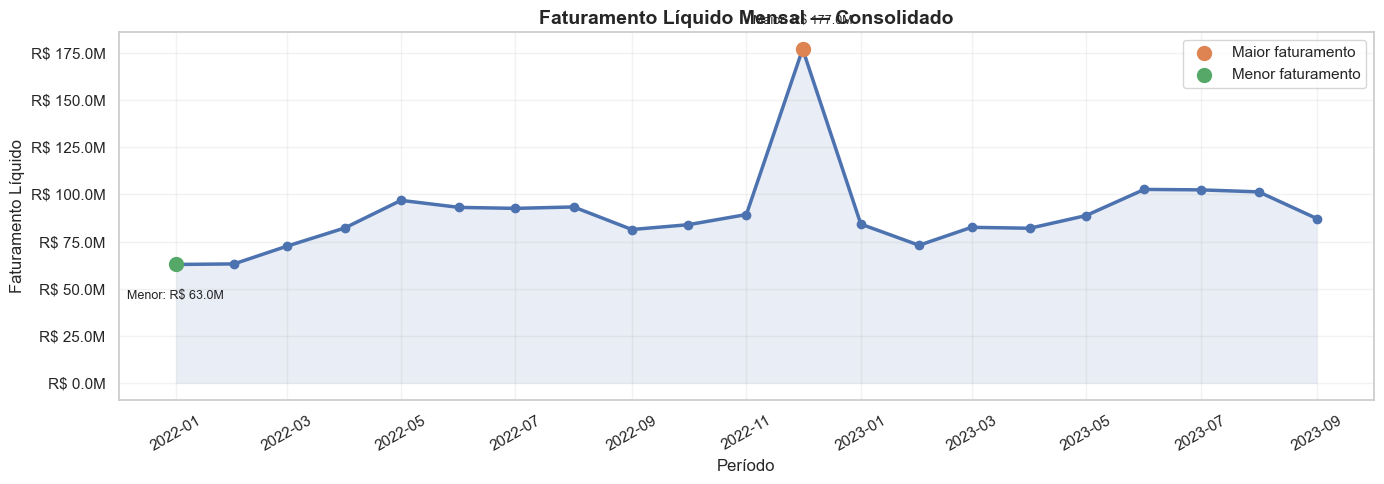

Faturamento médio mensal : R$ 90,168,719
Mês de maior faturamento : Dec/2022 — R$ 176,963,078
Mês de menor faturamento : Jan/2022 — R$ 62,950,047


In [31]:
### 10.2 Faturamento Mensal Consolidado

# Agregamos o faturamento líquido por mês.
# Essa visão mostra a evolução geral do faturamento da empresa ao longo do tempo.

fat_mensal = (
    df_eda
    .groupby('mes_referencia', as_index=False)
    .agg(
        FAT_LIQUIDO=('faturamento_liquido', 'sum'),
        QTD_TRANSACOES=('id_transacao', 'count')
    )
)

# Identificando meses de maior e menor faturamento.
idx_max = fat_mensal['FAT_LIQUIDO'].idxmax()
idx_min = fat_mensal['FAT_LIQUIDO'].idxmin()

mes_max = fat_mensal.loc[idx_max, 'mes_referencia']
valor_max = fat_mensal.loc[idx_max, 'FAT_LIQUIDO']

mes_min = fat_mensal.loc[idx_min, 'mes_referencia']
valor_min = fat_mensal.loc[idx_min, 'FAT_LIQUIDO']

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    fat_mensal['mes_referencia'],
    fat_mensal['FAT_LIQUIDO'],
    marker='o',
    linewidth=2.5
)

ax.fill_between(
    fat_mensal['mes_referencia'],
    fat_mensal['FAT_LIQUIDO'],
    alpha=0.12
)

# Destacando maior e menor mês.
ax.scatter(mes_max, valor_max, s=100, zorder=5, label='Maior faturamento')
ax.scatter(mes_min, valor_min, s=100, zorder=5, label='Menor faturamento')

ax.annotate(
    f'Maior: R$ {valor_max/1e6:.1f}M',
    xy=(mes_max, valor_max),
    xytext=(0, 18),
    textcoords='offset points',
    ha='center',
    fontsize=9
)

ax.annotate(
    f'Menor: R$ {valor_min/1e6:.1f}M',
    xy=(mes_min, valor_min),
    xytext=(0, -25),
    textcoords='offset points',
    ha='center',
    fontsize=9
)

ax.yaxis.set_major_formatter(fmt_brl_milhoes)
ax.set_title('Faturamento Líquido Mensal — Consolidado', fontsize=14, fontweight='bold')
ax.set_xlabel('Período')
ax.set_ylabel('Faturamento Líquido')
ax.legend()
ax.grid(alpha=0.25)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f'Faturamento médio mensal : R$ {fat_mensal["FAT_LIQUIDO"].mean():,.0f}')
print(f'Mês de maior faturamento : {mes_max.strftime("%b/%Y")} — R$ {valor_max:,.0f}')
print(f'Mês de menor faturamento : {mes_min.strftime("%b/%Y")} — R$ {valor_min:,.0f}')

### Análise — Faturamento Líquido Mensal Consolidado

> O gráfico mostra a evolução mensal do `faturamento_liquido` total da empresa ao longo do período analisado, considerando todas as lojas de forma consolidada.

> Observa-se que o faturamento apresenta crescimento ao longo de parte de 2022, com um pico bastante expressivo em dezembro de 2022, atingindo aproximadamente R$ 177 milhões. Esse comportamento pode indicar uma sazonalidade de fim de ano, possivelmente associada a maior volume de vendas, campanhas comerciais, datas comemorativas ou concentração de operações em determinadas lojas.

> Após o pico de dezembro, há uma queda relevante em janeiro de 2023, o que pode representar um comportamento esperado após meses de maior consumo. Mesmo assim, ao longo de 2023 o faturamento se mantém em um patamar relevante, especialmente entre maio e agosto.

> Esse gráfico é importante para a modelagem porque mostra que o `faturamento_liquido` não é constante ao longo do tempo. Existem tendência, picos e possíveis efeitos sazonais que deverão ser considerados na criação das variáveis temporais e na escolha dos modelos preditivos.

### 10.3 Faturamento Mensal por Loja

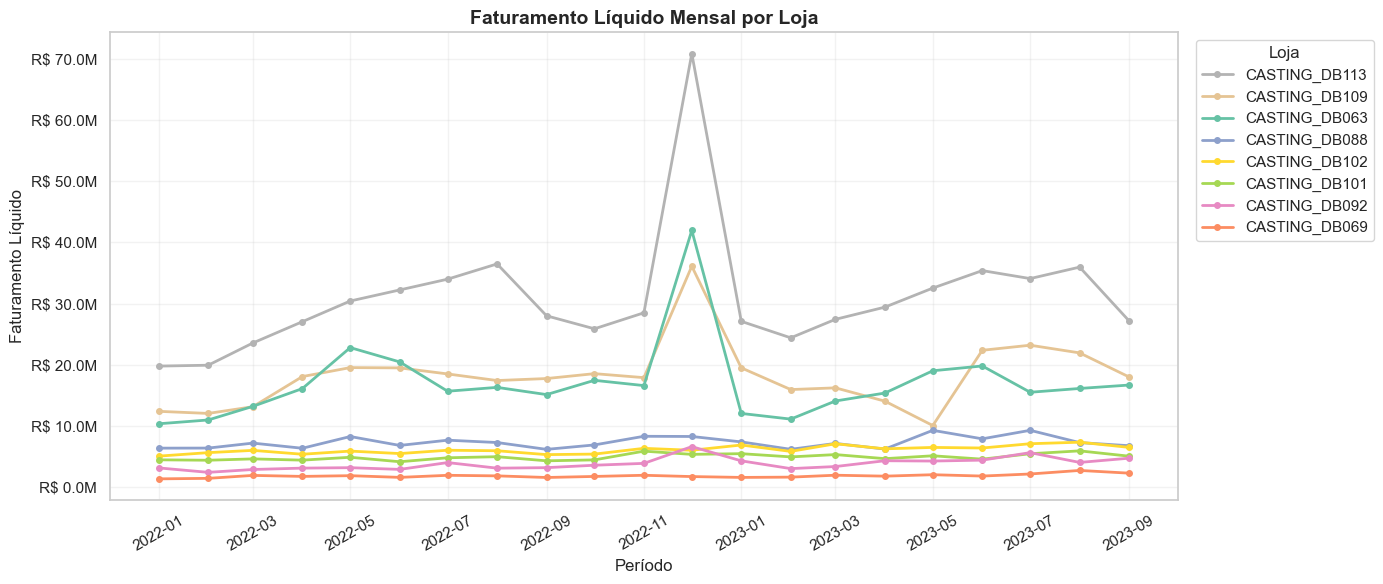

In [32]:
### 10.3 Faturamento Mensal por Loja

# Agora analisamos o faturamento mensal separado por loja.
# Essa visão é importante porque cada loja pode ter comportamento próprio,
# com volume, ticket e sazonalidade diferentes.

fat_loja_mensal = (
    df_eda
    .groupby(['mes_referencia', 'loja'], as_index=False)
    .agg(
        FAT_LIQUIDO=('faturamento_liquido', 'sum'),
        QTD_TRANSACOES=('id_transacao', 'count')
    )
)

# Ordenar as lojas pelo faturamento total facilita a leitura do gráfico e da tabela.
ordem_lojas = (
    fat_loja_mensal
    .groupby('loja')['FAT_LIQUIDO']
    .sum()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 6))

for loja in ordem_lojas:
    grp = fat_loja_mensal[fat_loja_mensal['loja'] == loja]
    
    ax.plot(
        grp['mes_referencia'],
        grp['FAT_LIQUIDO'],
        marker='o',
        markersize=4,
        linewidth=2,
        label=loja,
        color=cores_lojas[loja]
    )

ax.yaxis.set_major_formatter(fmt_brl_milhoes)
ax.set_title('Faturamento Líquido Mensal por Loja', fontsize=14, fontweight='bold')
ax.set_xlabel('Período')
ax.set_ylabel('Faturamento Líquido')
ax.legend(title='Loja', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.25)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Análise — Faturamento Líquido Mensal por Loja

> O gráfico mostra que o faturamento líquido mensal varia bastante entre as lojas. A `CASTING_DB113` se destaca como a loja de maior faturamento durante praticamente todo o período analisado, sendo também a principal responsável pelo pico observado em dezembro de 2022.

> As lojas `CASTING_DB109` e `CASTING_DB063` também possuem participação relevante no faturamento total, mas apresentam comportamentos diferentes. A `CASTING_DB063` mostra crescimento forte até dezembro de 2022 e depois queda, enquanto a `CASTING_DB109` mantém um faturamento expressivo em vários meses de 2023.

> As demais lojas possuem faturamento mensal menor, mas ainda apresentam padrões próprios de variação. Isso indica que as bases não possuem o mesmo comportamento comercial.

> Essa análise reforça que a modelagem deve considerar a dimensão loja. Uma abordagem por loja, ou pelo menos com `loja` como variável explicativa, tende a capturar melhor as diferenças de comportamento entre as unidades.

In [ ]:
# Resumo executivo por loja.
# Aqui usamos apenas vendas positivas para ticket médio e mediano,
# porque registros negativos representam devoluções/estornos e distorcem o ticket de venda.

resumo_loja = (
    df_eda
    .groupby('loja')
    .agg(
        Transacoes=('id_transacao', 'count'),
        Fat_Liquido_Total=('faturamento_liquido', 'sum'),
        Vendas_Positivas=('faturamento_liquido', lambda x: (x > 0).sum()),
        Registros_Negativos=('faturamento_liquido', lambda x: (x < 0).sum()),
        Ticket_Medio_Pos=('faturamento_liquido', lambda x: x[x > 0].mean()),
        Ticket_Mediano_Pos=('faturamento_liquido', lambda x: x[x > 0].median())
    )
    .round(2)
)

resumo_loja['Part_Fat_pct'] = (
    resumo_loja['Fat_Liquido_Total'] /
    resumo_loja['Fat_Liquido_Total'].sum() * 100
).round(2)

resumo_loja = resumo_loja.sort_values('Fat_Liquido_Total', ascending=False)

display(resumo_loja)

,Transacoes,Fat_Liquido_Total,Vendas_Positivas,Registros_Negativos,Ticket_Medio_Pos,Ticket_Mediano_Pos,Part_Fat_pct
loja,,,,,,,
CASTING_DB113,2381994,"650,267,356.19",2160978,220681,341.35,279.00,34.34
CASTING_DB109,1391362,"382,271,997.14",1300265,91007,318.75,244.99,20.19
CASTING_DB063,2853696,"356,879,171.77",2507998,8535,142.78,129.99,18.85
CASTING_DB088,274937,"153,528,645.37",270842,4090,576.73,359.00,8.11
CASTING_DB102,283595,"128,475,430.84",271246,12349,507.89,218.90,6.78
CASTING_DB101,223464,"103,266,167.94",209124,14340,543.26,362.00,5.45
CASTING_DB092,786938,"80,147,921.17",766093,20827,112.02,19.99,4.23
CASTING_DB069,93551,"38,706,418.39",90808,2743,440.97,270.00,2.04


> A análise por loja mostra que as bases possuem perfis de negócio diferentes. Algumas lojas concentram maior volume de faturamento, enquanto outras apresentam tickets médios e medianos mais altos.

> Essa diferença reforça a importância de considerar a modelagem por loja ou, no mínimo, incluir a loja como variável relevante na etapa de modelagem.

### 10.4 Devoluções e Registros Negativos ao longo do Tempo

In [34]:
### 10.4 Devoluções e Registros Negativos ao Longo do Tempo

# Nesta etapa avaliamos o impacto mensal dos registros com valor líquido negativo.
# Esses registros reduzem o faturamento real e podem representar devoluções, estornos ou ajustes financeiros.

devol_mensal = (
    df_eda
    .groupby('mes_referencia', as_index=False)
    .agg(
        FAT_BRUTO_POS=('valor_bruto_venda', lambda x: x[x > 0].sum()),
        VALOR_LIQ_NEG=('faturamento_liquido', lambda x: x[x < 0].sum()),
        FAT_LIQUIDO=('faturamento_liquido', 'sum'),
        QTD_REG_NEG=('faturamento_liquido', lambda x: (x < 0).sum()),
        QTD_TRANSACOES=('id_transacao', 'count')
    )
)

devol_mensal['TAXA_REG_NEG_PCT'] = (
    devol_mensal['VALOR_LIQ_NEG'].abs() /
    devol_mensal['FAT_BRUTO_POS'] * 100
).round(2)

devol_mensal['PCT_QTD_REG_NEG'] = (
    devol_mensal['QTD_REG_NEG'] /
    devol_mensal['QTD_TRANSACOES'] * 100
).round(2)

display(devol_mensal)

,mes_referencia,FAT_BRUTO_POS,VALOR_LIQ_NEG,FAT_LIQUIDO,QTD_REG_NEG,QTD_TRANSACOES,TAXA_REG_NEG_PCT,PCT_QTD_REG_NEG
0,2022-01-01,"88,972,665.71","-8,333,571.56","62,950,046.56",26729,353815,9.37,7.55
1,2022-02-01,"85,871,207.04","-4,636,944.78","63,242,956.83",13249,309294,5.40,4.28
2,2022-03-01,"96,896,354.54","-5,070,726.57","72,555,715.41",13879,339287,5.23,4.09
3,2022-04-01,"106,738,340.02","-5,497,629.06","82,247,273.55",13922,359495,5.15,3.87
4,2022-05-01,"123,779,764.26","-6,925,815.46","96,883,385.39",17105,413699,5.60,4.13
5,2022-06-01,"120,550,187.90","-7,133,867.21","93,159,749.70",17031,393374,5.92,4.33
6,2022-07-01,"126,460,921.25","-6,119,695.92","92,640,647.28",16152,416375,4.84,3.88
7,2022-08-01,"128,133,993.90","-8,658,352.88","93,391,750.69",21709,409370,6.76,5.30
8,2022-09-01,"107,914,482.55","-6,214,736.02","81,447,526.21",15906,357312,5.76,4.45
9,2022-10-01,"107,931,913.16","-5,976,701.54","83,990,468.74",14858,380251,5.54,3.91


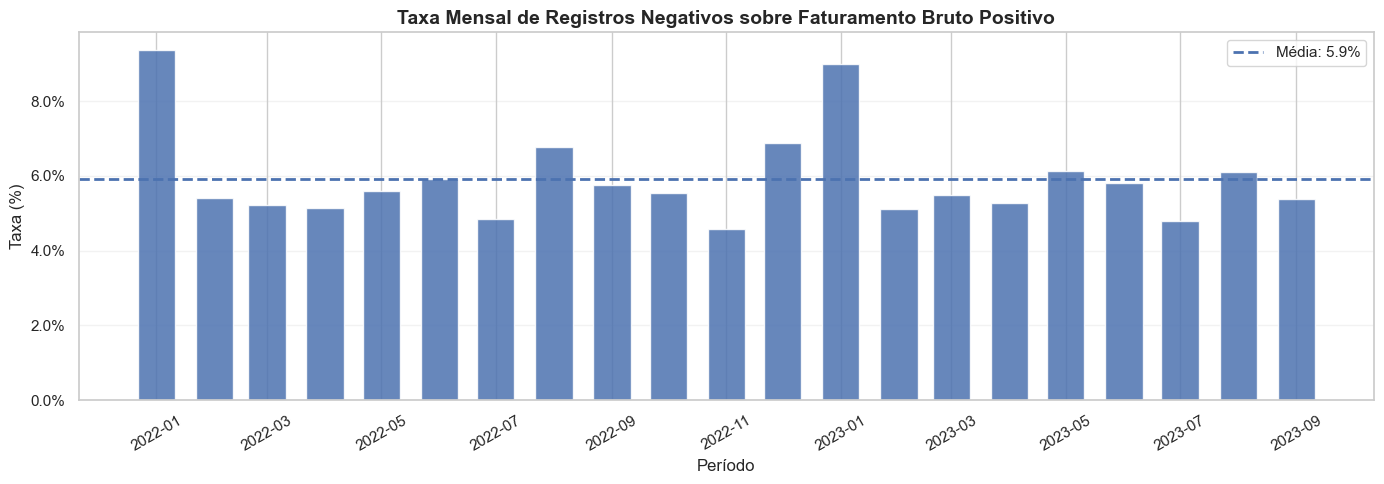

Taxa média de registros negativos : 5.9%
Maior taxa mensal                : 9.4% em Jan/2022


In [35]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    devol_mensal['mes_referencia'],
    devol_mensal['TAXA_REG_NEG_PCT'],
    width=20,
    alpha=0.85
)

media_taxa = devol_mensal['TAXA_REG_NEG_PCT'].mean()

ax.axhline(
    media_taxa,
    linestyle='--',
    linewidth=2,
    label=f'Média: {media_taxa:.1f}%'
)

ax.yaxis.set_major_formatter(fmt_pct)
ax.set_title('Taxa Mensal de Registros Negativos sobre Faturamento Bruto Positivo', fontsize=14, fontweight='bold')
ax.set_xlabel('Período')
ax.set_ylabel('Taxa (%)')
ax.legend()
ax.grid(axis='y', alpha=0.25)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

idx_max_dev = devol_mensal['TAXA_REG_NEG_PCT'].idxmax()

print(f'Taxa média de registros negativos : {media_taxa:.1f}%')
print(
    f'Maior taxa mensal                : {devol_mensal.loc[idx_max_dev, "TAXA_REG_NEG_PCT"]:.1f}% '
    f'em {devol_mensal.loc[idx_max_dev, "mes_referencia"].strftime("%b/%Y")}'
)

### Análise — Taxa Mensal de Registros Negativos

> O gráfico apresenta a taxa mensal de registros negativos em relação ao faturamento bruto positivo. Esses registros podem representar devoluções, estornos ou ajustes financeiros que reduzem o faturamento líquido real.

> A taxa média ficou próxima de 5,9%, indicando que registros negativos fazem parte da dinâmica recorrente do negócio e não devem ser tratados como erro automático.

> Os maiores picos aparecem em janeiro de 2022 e dezembro de 2022. O pico de dezembro chama atenção porque coincide com o maior faturamento da série, sugerindo que meses com maior volume de vendas também podem concentrar maior impacto de devoluções, estornos ou ajustes.

> Para a modelagem, a principal decisão é manter esses registros na base, pois eles afetam diretamente o `faturamento_liquido` real. Removê-los poderia gerar uma previsão artificialmente otimista.

### 10.5 Sazonalidade por loja

In [36]:
### 10.5 Sazonalidade por Loja

# Primeiro verificamos se todas as lojas possuem série mensal completa.
# Isso é importante porque lacunas temporais prejudicam análise de sazonalidade e modelagem.

n_meses_total = df_eda['mes_referencia'].nunique()

meses_por_loja = (
    df_eda
    .groupby(['loja', 'mes_referencia'])
    .size()
    .reset_index(name='qtd_registros')
    .groupby('loja')['mes_referencia']
    .nunique()
)

lojas_completas = meses_por_loja[meses_por_loja == n_meses_total].index.tolist()
lojas_incompletas = meses_por_loja[meses_por_loja < n_meses_total].to_dict()

print(f'Meses no período analisado : {n_meses_total}')
print(f'Lojas com série completa   : {sorted(lojas_completas)}')
print(f'Lojas com lacunas          : {lojas_incompletas}')

Meses no período analisado : 21
Lojas com série completa   : ['CASTING_DB063', 'CASTING_DB069', 'CASTING_DB088', 'CASTING_DB092', 'CASTING_DB101', 'CASTING_DB102', 'CASTING_DB109', 'CASTING_DB113']
Lojas com lacunas          : {}


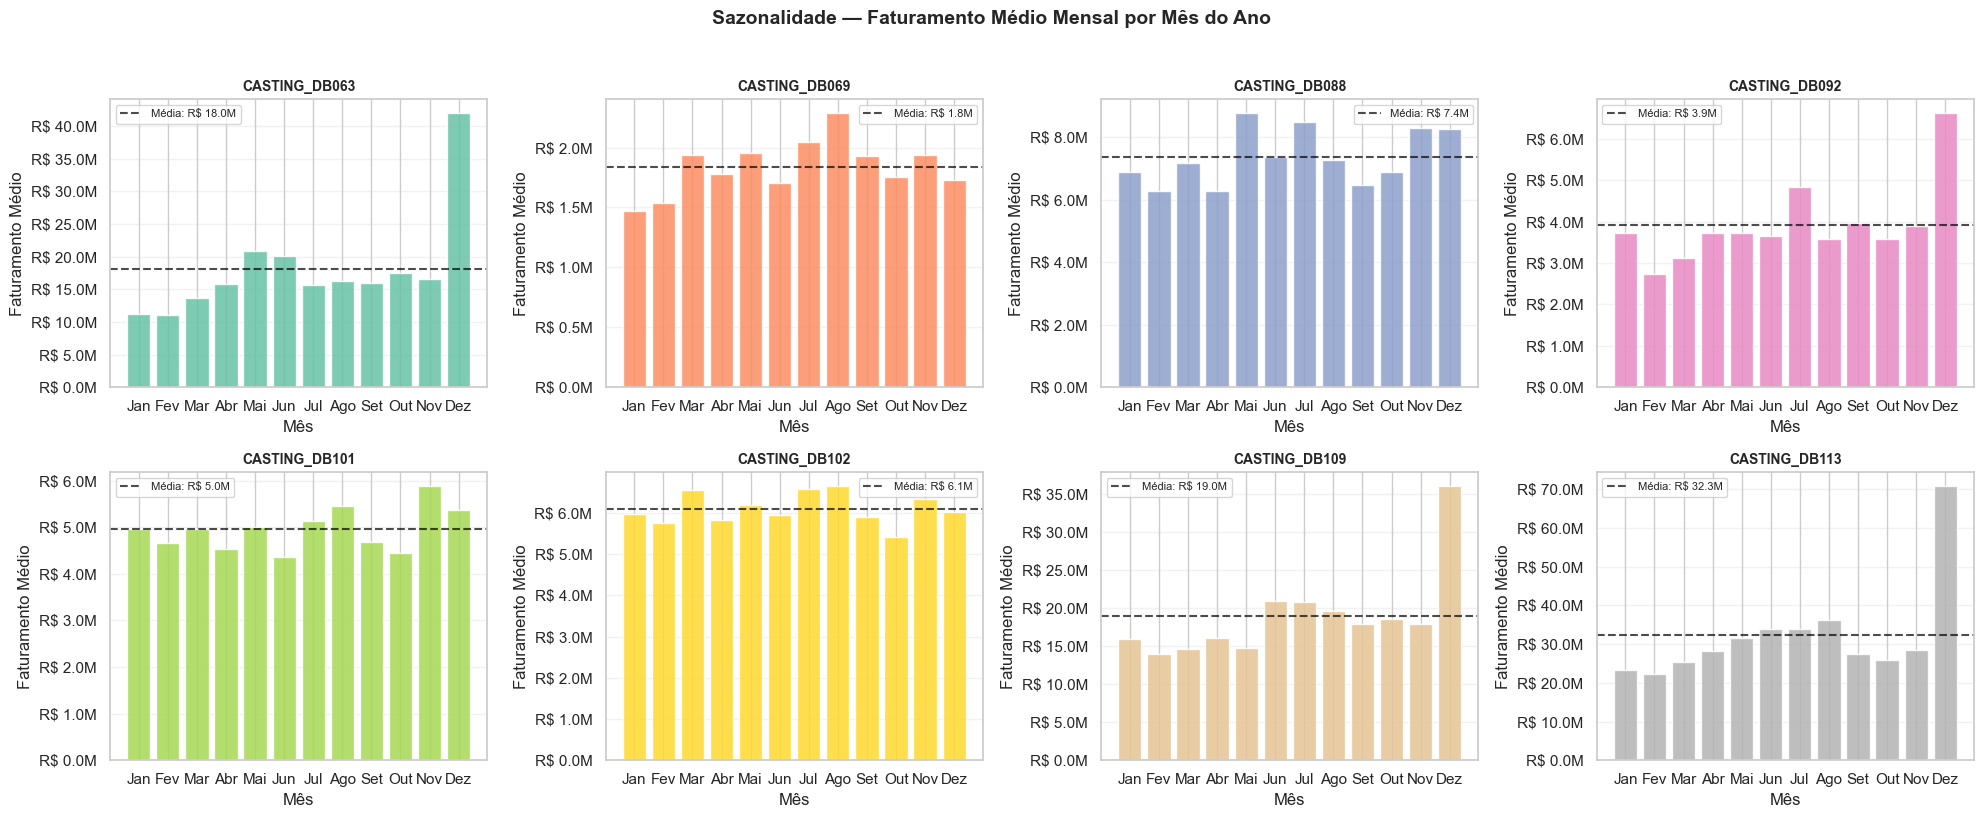

In [ ]:
# Agregamos primeiro por loja e mês.
# Depois calculamos a média por mês do ano para avaliar sazonalidade.

fat_mensal_loja = (
    df_eda
    .groupby(['loja', 'mes_referencia'], as_index=False)
    .agg(faturamento_liquido_mensal=('faturamento_liquido', 'sum'))
)

fat_mensal_loja['mes'] = fat_mensal_loja['mes_referencia'].dt.month

sazonalidade_loja = (
    fat_mensal_loja
    .groupby(['loja', 'mes'], as_index=False)
    .agg(FAT_MEDIO_MENSAL=('faturamento_liquido_mensal', 'mean'))
)

meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
               'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

sazonalidade_loja['MES_NOME'] = sazonalidade_loja['mes'].apply(lambda x: meses_nomes[x - 1])

n_lojas = len(lojas_completas)
n_cols = 4
n_rows = int(np.ceil(n_lojas / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for idx, loja in enumerate(sorted(lojas_completas)):
    dados_loja = sazonalidade_loja[sazonalidade_loja['loja'] == loja]

    ax = axes_flat[idx]

    ax.bar(
        dados_loja['MES_NOME'],
        dados_loja['FAT_MEDIO_MENSAL'],
        alpha=0.85,
        color=cores_lojas[loja]
        )

    media_loja = dados_loja['FAT_MEDIO_MENSAL'].mean()

    ax.axhline(
        media_loja,
        linestyle='--',
        linewidth=1.5,
        color='black',
        alpha=0.7,
        label=f'Média: R$ {media_loja/1e6:.1f}M'
        )

    ax.yaxis.set_major_formatter(fmt_brl_milhoes)
    ax.set_title(loja, fontsize=10, fontweight='bold')
    ax.set_xlabel('Mês')
    ax.set_ylabel('Faturamento Médio')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)

# Ocultar eixos extras caso existam.
for idx in range(n_lojas, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(
    'Sazonalidade — Faturamento Médio Mensal por Mês do ano',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Análise — Sazonalidade por Loja

> O gráfico de sazonalidade mostra o faturamento médio mensal por mês do ano para cada loja. A análise permite entender se determinados meses apresentam comportamento acima ou abaixo da média de cada base.

> Algumas lojas apresentam picos bem definidos em dezembro, principalmente `CASTING_DB063`, `CASTING_DB109` e `CASTING_DB113`. Esse comportamento reforça a hipótese de sazonalidade de fim de ano, já observada no gráfico consolidado.

> Outras lojas, como `CASTING_DB101` e `CASTING_DB102`, apresentam comportamento mais estável, com menor variação entre os meses. Isso mostra que a sazonalidade não é igual para todas as lojas.

> Essa diferença é importante para a modelagem, pois indica que o mês do ano pode ser uma variável relevante, mas seu efeito pode variar conforme a loja. Portanto, a modelagem por loja ou a inclusão da variável `loja` pode ajudar o modelo a capturar melhor esses padrões.

### 10.6 Distribuição do Ticket por Loja

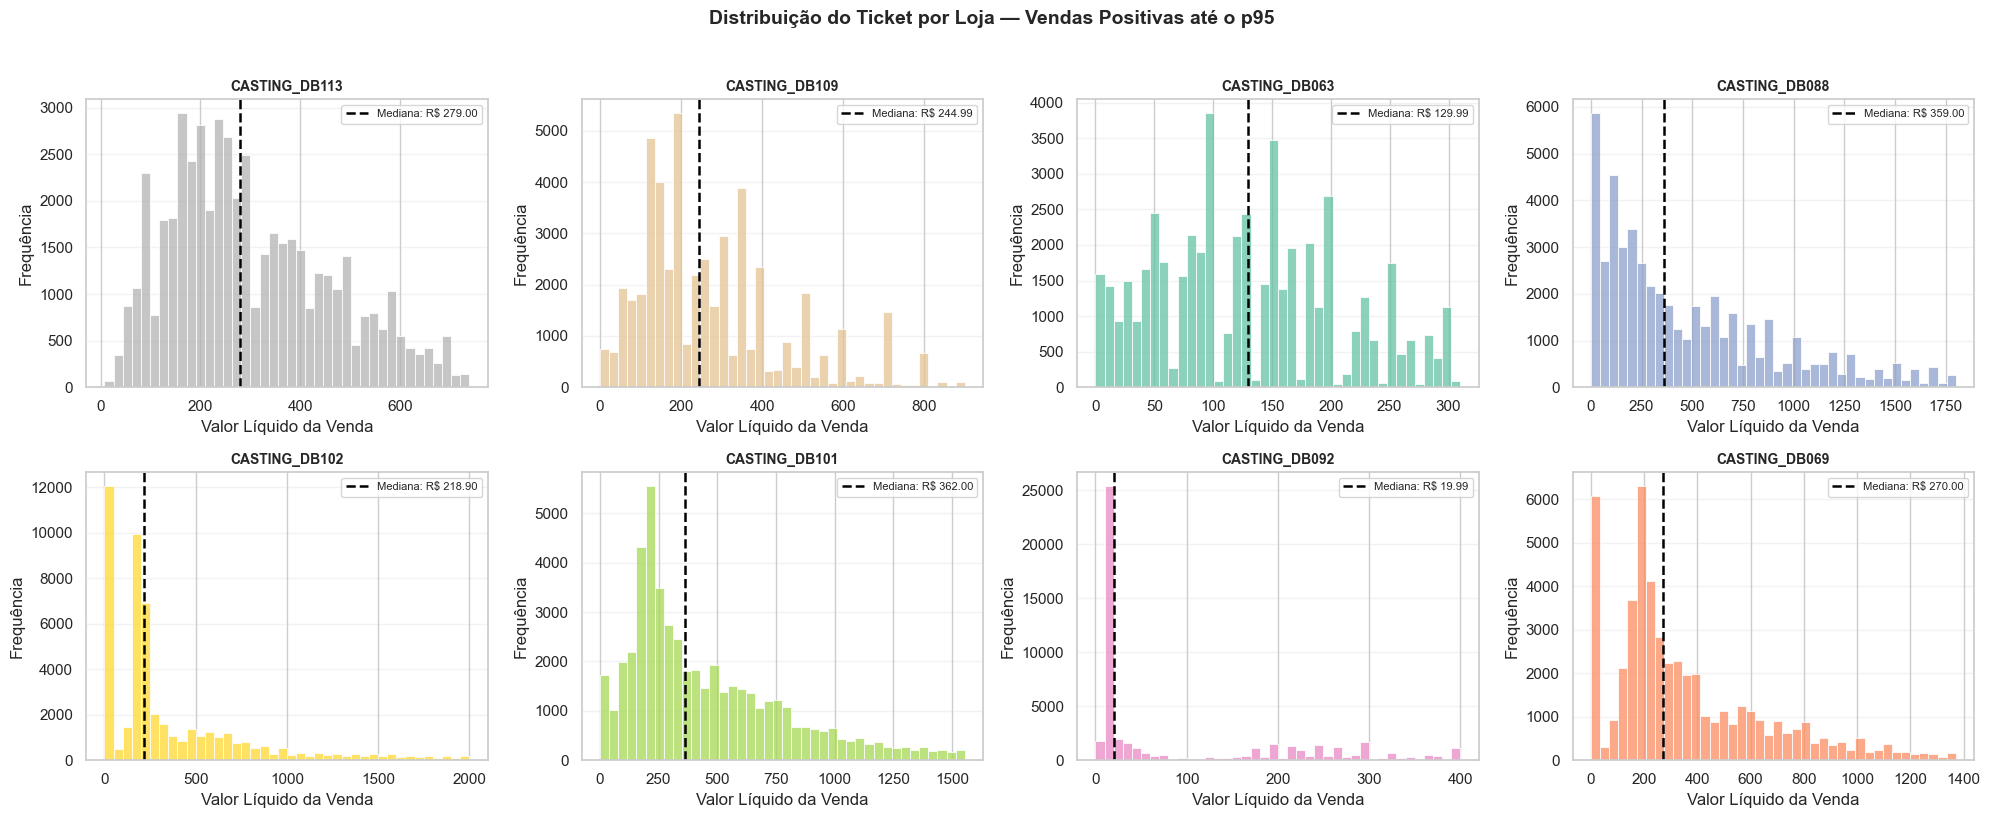

In [38]:
### 10.6 Distribuição do Ticket por Loja

# A distribuição do ticket ajuda a entender o perfil de venda de cada loja.
# Para evitar que outliers extremos distorçam os histogramas, limitamos a visualização até o p95 de cada loja.

vendas_pos = df_eda[df_eda['faturamento_liquido'] > 0].copy()

lojas_ord = (
    vendas_pos
    .groupby('loja')['faturamento_liquido']
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

n_lojas = len(lojas_ord)
n_cols = 4
n_rows = int(np.ceil(n_lojas / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for idx, loja in enumerate(lojas_ord):
    grp = vendas_pos[vendas_pos['loja'] == loja]['faturamento_liquido']

    p95 = grp.quantile(0.95)
    mediana = grp.median()

    # Amostra para deixar o gráfico mais leve, sem perder a visão geral da distribuição.
    grp_plot = grp[grp <= p95]

    if len(grp_plot) > 50000:
        grp_plot = grp_plot.sample(50000, random_state=42)

    ax = axes_flat[idx]

    sns.histplot(
        grp_plot,
        bins=40,
        ax=ax,
        color=cores_lojas[loja]
    )

    ax.axvline(
        mediana,
        linestyle='--',
        linewidth=1.8,
        color='black',
        label=f'Mediana: R$ {mediana:,.2f}'
    )

    ax.set_title(loja, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor Líquido da Venda')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)

for idx in range(n_lojas, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(
    'Distribuição do Ticket por Loja — Vendas Positivas até o p95',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Análise — Distribuição do Ticket por Loja

> O gráfico mostra a distribuição do valor líquido das vendas positivas por loja, limitando a visualização até o percentil 95 para reduzir o efeito visual dos outliers extremos.

> A análise evidencia que as lojas possuem perfis de ticket bastante diferentes. Algumas concentram grande volume de vendas em valores mais baixos, enquanto outras apresentam tickets medianos mais elevados e maior dispersão.

> A `CASTING_DB092`, por exemplo, possui forte concentração em tickets baixos, com mediana próxima de R$ 19,99. Já lojas como `CASTING_DB088`, `CASTING_DB101`, `CASTING_DB102` e `CASTING_DB069` apresentam tickets medianos mais altos, indicando possível diferença no mix de produtos, perfil de clientes ou estratégia comercial.

> Essa análise mostra que o faturamento não depende apenas da quantidade de transações, mas também do valor médio das vendas. Para a modelagem, isso reforça que cada loja pode ter uma dinâmica própria de faturamento.

### 10.7 Outliers de Alto Valor por Loja

In [39]:
### 10.7 Outliers de Alto Valor por Loja

# Como cada loja possui um padrão de ticket diferente,
# o limiar de outlier deve ser calculado por loja.
# Usamos o percentil 99 como referência para identificar transações de alto valor.

p99_por_loja = (
    vendas_pos
    .groupby('loja')['faturamento_liquido']
    .quantile(0.99)
    .rename('Limiar_p99')
)

fat_max_por_loja = (
    vendas_pos
    .groupby('loja')['faturamento_liquido']
    .max()
    .rename('Fat_Max')
)

resumo_outliers = pd.concat([p99_por_loja, fat_max_por_loja], axis=1)

resumo_outliers['Razao_Max_p99'] = (
    resumo_outliers['Fat_Max'] /
    resumo_outliers['Limiar_p99']
).round(2)

display(resumo_outliers.sort_values('Fat_Max', ascending=False))

,Limiar_p99,Fat_Max,Razao_Max_p99
loja,,,
CASTING_DB113,"1,260.00","72,800.00",57.78
CASTING_DB109,"1,299.99","62,497.50",48.08
CASTING_DB088,"2,999.00","27,992.00",9.33
CASTING_DB101,"2,713.93","15,432.99",5.69
CASTING_DB102,"4,005.82","15,125.00",3.78
CASTING_DB069,"2,569.99","9,159.24",3.56
CASTING_DB092,549.99,"2,519.88",4.58
CASTING_DB063,449.99,"1,199.99",2.67


In [40]:
print('Top 3 transações de maior valor por loja:')

top3_outliers = (
    vendas_pos
    .sort_values('faturamento_liquido', ascending=False)
    .groupby('loja')
    .head(3)
    [
        [
            'loja',
            'data_venda',
            'id_transacao',
            'qtd_produtos',
            'valor_bruto_venda',
            'valor_desconto',
            'faturamento_liquido'
        ]
    ]
    .sort_values(['loja', 'faturamento_liquido'], ascending=[True, False])
)

display(top3_outliers)

Top 3 transações de maior valor por loja:


,loja,data_venda,id_transacao,qtd_produtos,valor_bruto_venda,valor_desconto,faturamento_liquido
639475,CASTING_DB063,2022-10-31,F45CE243-8F5E-4A77-819D-1682DF2CF0D0,1.00,"1,199.99",0.00,"1,199.99"
639476,CASTING_DB063,2022-10-31,6887C7A5-5731-467A-9F7F-BC0EEF5FA21C,1.00,"1,199.99",0.00,"1,199.99"
1117789,CASTING_DB063,2023-01-07,A540B097-3337-434E-983F-9836FEC3D704,1.00,"1,199.99",0.00,"1,199.99"
2887761,CASTING_DB069,2023-05-04,4D06EB2C-A095-4A2C-A9CC-901BD0FDFECC,2.00,"11,813.00","2,653.76","9,159.24"
2887769,CASTING_DB069,2023-05-04,350F07E9-F6A8-465C-96F7-C5339B1461A4,2.00,"11,813.00","2,653.76","9,159.24"
2906017,CASTING_DB069,2023-06-06,61CB414A-E349-4F16-AA6C-68DAD92FD6C4,2.00,"12,275.00","3,437.00","8,838.00"
2967278,CASTING_DB088,2023-02-24,5F480707-DAD0-4560-990B-C1A4B35983E2,8.00,"27,992.00",0.00,"27,992.00"
2976277,CASTING_DB088,2023-08-24,31540B19-1F43-4391-82A9-99CAE980599B,5.00,"18,995.00",0.00,"18,995.00"
3216103,CASTING_DB088,2022-04-28,6538135A-2F79-4190-AC08-9C41606A9390,400.00,"17,400.00",0.00,"17,400.00"
3568669,CASTING_DB092,2022-09-28,B509EB64-D50A-40BC-8A1D-BC02C6470169,14.00,"2,799.86",279.98,"2,519.88"


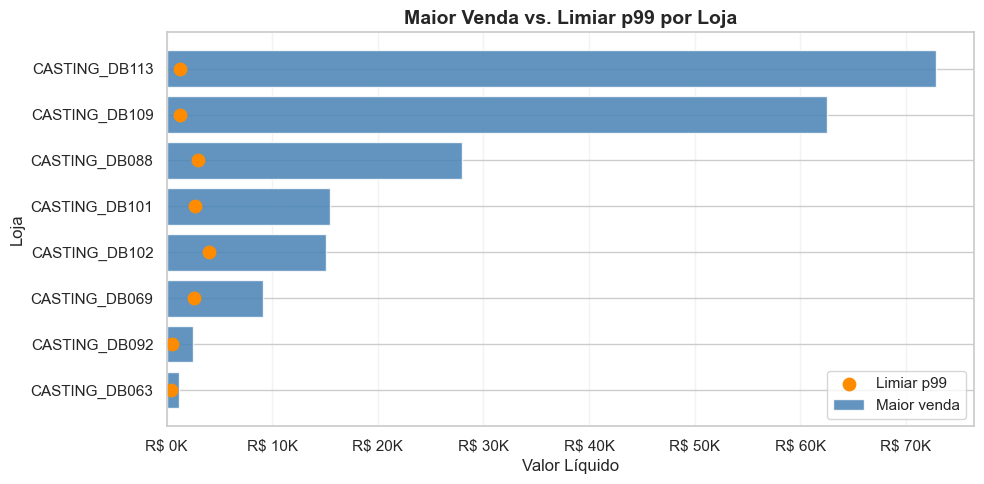

In [41]:
resumo_plot = resumo_outliers.sort_values('Fat_Max', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    resumo_plot.index,
    resumo_plot['Fat_Max'],
    alpha=0.85,
    label='Maior venda',
    color='steelblue'
)

ax.scatter(
    resumo_plot['Limiar_p99'],
    resumo_plot.index,
    s=80,
    label='Limiar p99',
    color='darkorange'
)

ax.xaxis.set_major_formatter(fmt_brl_milhares)
ax.set_title('Maior Venda vs. Limiar p99 por Loja', fontsize=14, fontweight='bold')
ax.set_xlabel('Valor Líquido')
ax.set_ylabel('Loja')
ax.legend()
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

### Análise — Outliers de Alto Valor por Loja

> O gráfico compara a maior venda registrada em cada loja com o limiar do percentil 99 da própria loja. Essa abordagem é importante porque cada base possui um padrão diferente de ticket.

> Lojas como `CASTING_DB113` e `CASTING_DB109` apresentam vendas máximas muito acima do p99, indicando transações de valor bastante elevado em relação ao padrão da própria loja. Esses casos podem representar vendas reais de maior quantidade, operações de atacado ou eventos comerciais específicos.

> Como essas transações fazem parte do faturamento real da empresa, elas não devem ser removidas automaticamente. A melhor decisão é mantê-las na base e, na etapa de tratamento, criar uma flag para identificar vendas de alto valor por loja.

> Dessa forma, o modelo poderá reconhecer esse tipo de comportamento sem perder informações importantes do faturamento.

# Conclusão Geral da Exploração dos Dados

> A etapa de exploração dos dados permitiu compreender a estrutura da base histórica de faturamento, avaliar sua qualidade e identificar padrões relevantes para o desenvolvimento do modelo preditivo.

> Foi identificado que a base possui um grande volume de registros transacionais, distribuídos entre diferentes lojas e abrangendo o período de janeiro de 2022 a outubro de 2023. Durante a análise, verificou-se que outubro de 2023 continha apenas registros parciais, sendo considerado um mês incompleto e, por esse motivo, removido das análises mensais e da etapa de modelagem.

> A avaliação da qualidade dos dados mostrou baixa ocorrência de valores ausentes e ausência de duplicidades relevantes, indicando boa consistência da base utilizada. Também foi identificado que o identificador das transações apresentou comportamento consistente como chave única dos registros.

> Na validação das informações financeiras, observou-se que o cálculo simplificado do faturamento líquido a partir do valor bruto da venda e dos descontos não reproduzia integralmente os valores registrados na base. Como não foram encontradas variáveis adicionais capazes de explicar essas diferenças, foi adotado como referência o `faturamento_liquido`, por representar o valor financeiro efetivamente registrado nas transações.

> Também foram identificados registros com `faturamento_liquido` negativo, associados a devoluções, estornos ou ajustes financeiros. Como esses eventos fazem parte da operação do negócio e impactam diretamente o faturamento, optou-se por preservá-los durante a preparação dos dados.

> A análise temporal evidenciou variações relevantes no faturamento ao longo do período analisado, incluindo picos expressivos em determinados meses, indicando a presença de sazonalidade que poderia ser explorada durante a modelagem preditiva.

> A análise por loja mostrou diferenças significativas entre as unidades, tanto em volume de faturamento quanto no comportamento dos tickets de venda. Da mesma forma, a identificação de transações de alto valor demonstrou que cada loja possui características próprias, tornando mais adequado avaliar esses registros individualmente, utilizando limites específicos para cada unidade em vez de um único critério para toda a base.


# Principais Insights da Exploração

> A análise exploratória forneceu informações importantes para orientar todas as etapas seguintes do projeto. Entre os principais insights obtidos, destacam-se:

- identificação de padrões sazonais no comportamento do faturamento ao longo do tempo;
- diferenças relevantes no desempenho entre as lojas;
- forte dependência temporal da série histórica, justificando a criação de variáveis como atrasos temporais (*lags*) e médias móveis;
- necessidade de preservar registros negativos e transações de alto valor, por representarem eventos reais do negócio;
- utilização do `faturamento_liquido` como variável oficial para treinamento e avaliação do modelo.

> Esses resultados serviram como base para a definição das estratégias de tratamento dos dados, engenharia de atributos e construção do modelo preditivo.

> A exploração dos dados demonstrou que a qualidade das informações, aliada ao entendimento do contexto de negócio, foi fundamental para desenvolver uma solução capaz de realizar previsões de faturamento de forma consistente e alinhada às necessidades de tomada de decisão.